## 数据输入
1.1 学生基本信息（含三门选科＋总分）
1.2 2023 分数分布表 → score_pct
1.3 学校/专业历年最低分、平均分
1.4 6 选 3 ↔ MBTI 映射表 ✅

特征工程
2.1 score_pct、sub_popularity
2.2 mbti_pred → one-hot / label encode

协同过滤 (SVD)

逻辑回归 / 大类专属模型
特征 = 分数 + 专业分数线 + MBTI one-hot

推荐打分
0.45 P(admit) + 0.25 MBTI_match + 0.20 CF + 0.10 subject_match

可视化 & 导出
– 分数分布曲线
– MBTI 预测分布饼图
– Top-N 推荐条形图

文档/报告生成
Markdown/Word，附表＋图

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# 1. 定义文件路径（全部用 .txt 文件）
PATH_COMBO_MBTI = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\subject_combo_to_mbti.txt")
PATH_MAJOR      = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\2023上海专业分数线.txt")
PATH_SCORE_DIST = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\2023年考生高考成绩分布表（上海市）.txt")

In [4]:
# 2. 读取数据，全部用 tab 分隔符（'\t'），且加 encoding="utf-8-sig" 保证兼容性
df_combo = pd.read_csv(PATH_COMBO_MBTI, sep='\t', encoding='utf-8-sig')
df_major = pd.read_csv(PATH_MAJOR, sep='\t', encoding='utf-8-sig')
df_score = pd.read_csv(PATH_SCORE_DIST, sep='\t', encoding='utf-8-sig')


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Lenovo\\Desktop\\志愿填报辅助系统\\上海高考录取数据17-23年\\用到的\\subject_combo_to_mbti.txt'

In [4]:
# 3. 对应列名（如有不同请检查 txt 头部改这里）
df_combo = df_combo.rename(columns={
    "mbti": "MBTI",
    "count": "人数count",
    "subject_combo": "选科组合"
})

In [5]:
# 4. 按 MBTI 累加总人数，得到全体分布
mbti_pie = df_combo.groupby("MBTI")["人数count"].sum().sort_values(ascending=False)

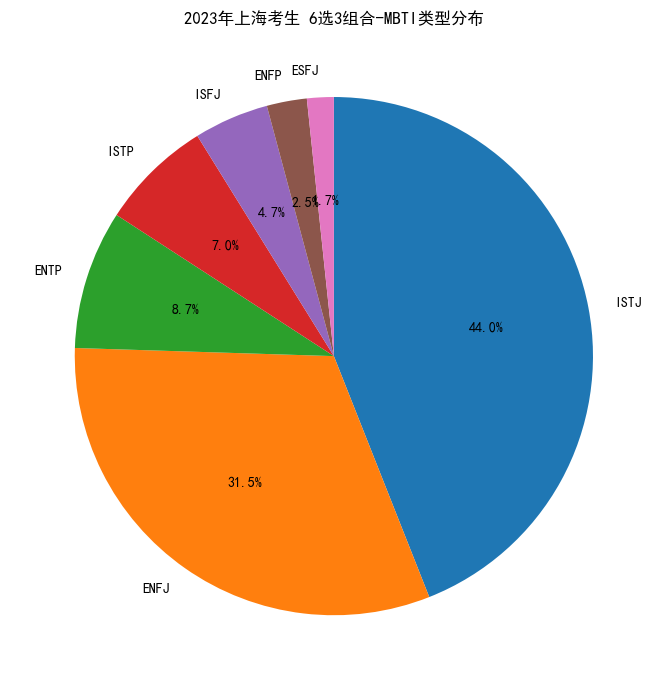

饼图已保存：C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\fig_mbti_pie_2023.png


In [6]:
# 5. 绘制饼图
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 1. 指定黑体字体路径（Windows自带）
font_path = "C:/Windows/Fonts/simhei.ttf"
simhei_font = font_manager.FontProperties(fname=font_path)

# 2. 全局设置字体
plt.rcParams['font.family'] = simhei_font.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示


# 3. 直接用原先的画图代码即可
plt.figure(figsize=(7, 7))
plt.pie(
    mbti_pie,
    labels=mbti_pie.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
plt.title("2023年上海考生 6选3组合-MBTI类型分布")
plt.tight_layout()
OUT_FIG = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\fig_mbti_pie_2023.png")
plt.savefig(OUT_FIG, dpi=300)
plt.show()

print(f"饼图已保存：{OUT_FIG}")

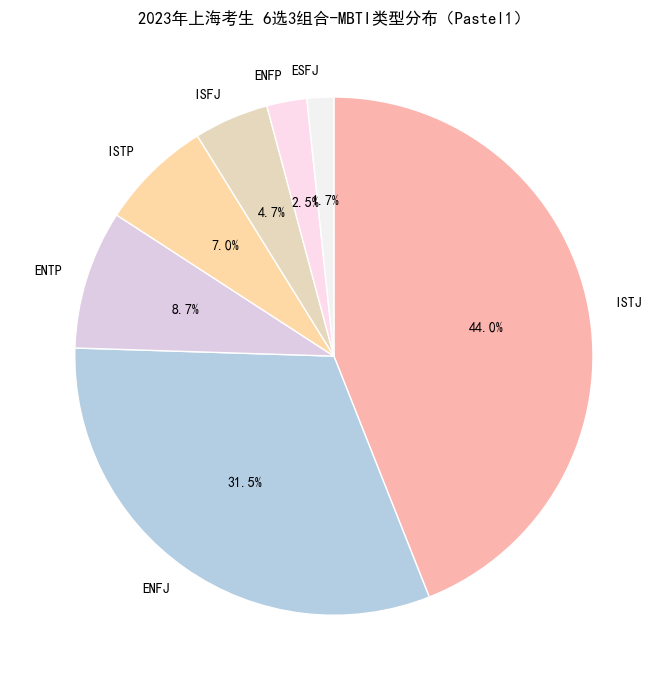

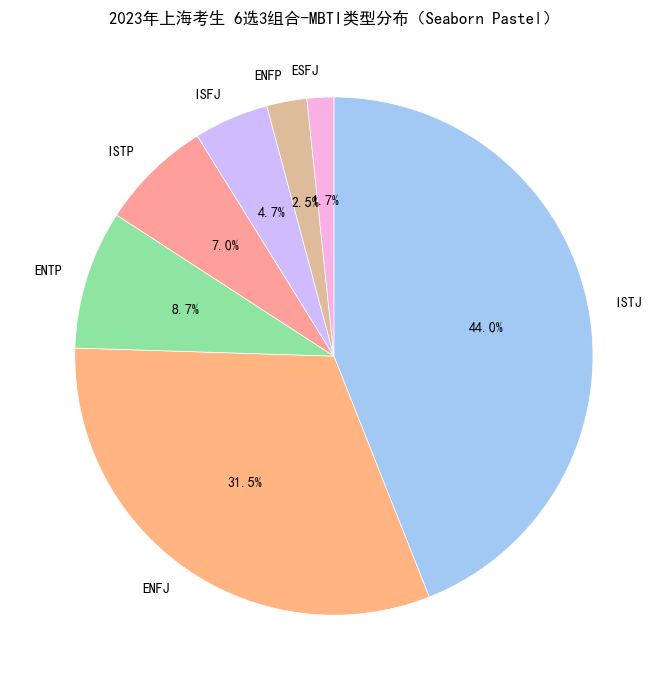

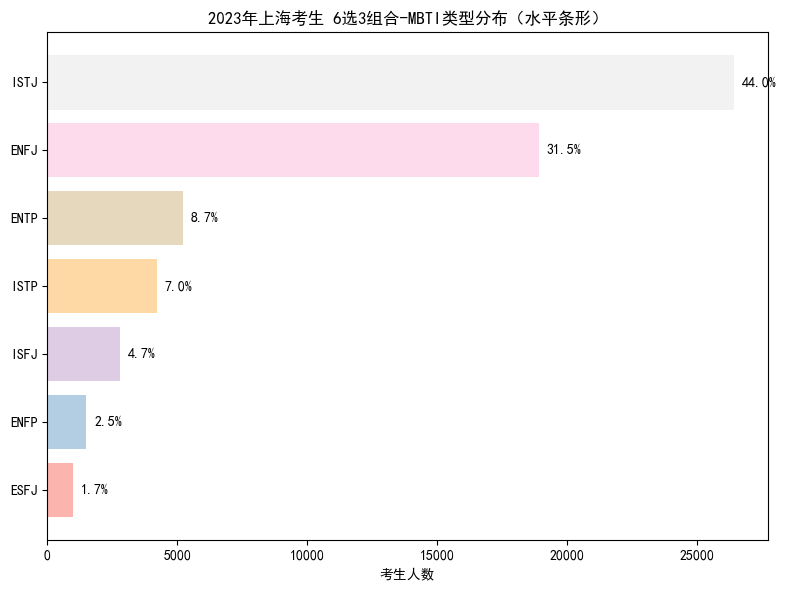

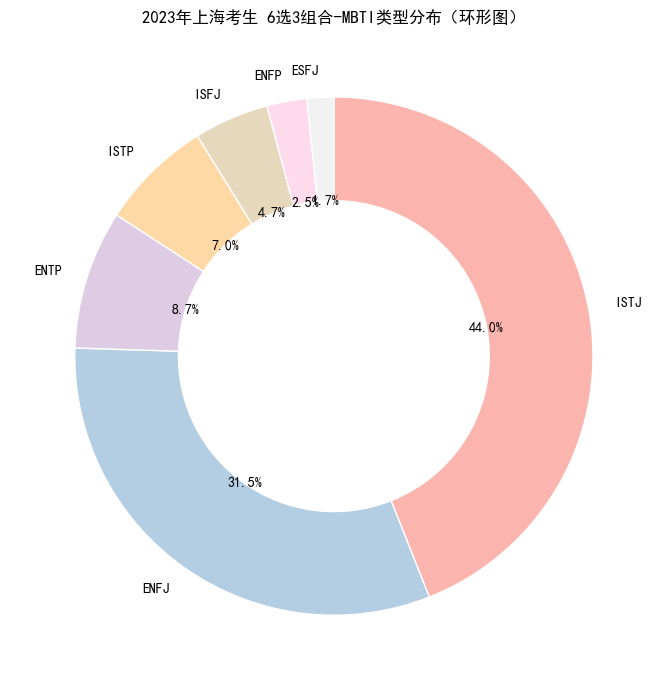

所有图表已保存到： C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path

# —— 1. 字体配置（Windows 黑体） ——
font_path = "C:/Windows/Fonts/simhei.ttf"
simhei_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family']        = simhei_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示

# —— 2. 准备数据 —— 
# 假设 mbti_pie 已经存在：
# mbti_pie = df_mbti.groupby("MBTI")["人数count"].sum()
labels = mbti_pie.index
sizes  = mbti_pie.values
total  = sizes.sum()

# —— 3. 输出目录 —— 
OUT_DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# —— 4. Matplotlib Pastel1 柔和饼图 —— 
cmap      = plt.get_cmap('Pastel1')
colors_p1 = cmap(np.linspace(0, 1, len(labels)))

fig1, ax1 = plt.subplots(figsize=(7,7))
ax1.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors_p1,
    wedgeprops={'edgecolor':'white'}
)
ax1.set_title("2023年上海考生 6选3组合-MBTI类型分布（Pastel1）")
plt.tight_layout()
fig1.savefig(OUT_DIR/"mbti_pie_pastel1.png", dpi=300)
plt.show()


# —— 5. Seaborn “pastel” 调色板饼图 —— 
palette = sns.color_palette("pastel", len(labels))
fig2, ax2 = plt.subplots(figsize=(7,7))
ax2.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=palette,
    wedgeprops={'linewidth':0.5, 'edgecolor':'white'}
)
ax2.set_title("2023年上海考生 6选3组合-MBTI类型分布（Seaborn Pastel）")
plt.tight_layout()
fig2.savefig(OUT_DIR/"mbti_pie_seaborn_pastel.png", dpi=300)
plt.show()


# —— 6. 水平条形图 —— 
mbti_sorted = mbti_pie.sort_values(ascending=True)
colors_bar  = cmap(np.linspace(0, 1, len(mbti_sorted)))

fig3, ax3 = plt.subplots(figsize=(8,6))
ax3.barh(
    mbti_sorted.index,
    mbti_sorted.values,
    color=colors_bar
)
for value, mbti in zip(mbti_sorted.values, mbti_sorted.index):
    pct = value / total
    ax3.text(
        value + total*0.005,
        mbti,
        f"{pct:.1%}",
        va='center'
    )
ax3.set_xlabel("考生人数")
ax3.set_title("2023年上海考生 6选3组合-MBTI类型分布（水平条形）")
plt.tight_layout()
fig3.savefig(OUT_DIR/"mbti_barh_pastel1.png", dpi=300)
plt.show()


# —— 7. 环形图 (Donut) —— 
fig4, ax4 = plt.subplots(figsize=(7,7))
ax4.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors_p1,
    wedgeprops={'width':0.4, 'edgecolor':'white'}
)
ax4.set_title("2023年上海考生 6选3组合-MBTI类型分布（环形图）")
plt.tight_layout()
fig4.savefig(OUT_DIR/"mbti_donut_pastel1.png", dpi=300)
plt.show()


print("所有图表已保存到：", OUT_DIR.resolve())


## 2.数据清洗与预处理

In [20]:
# 0. 环境准备
import pandas as pd
from pathlib import Path

In [21]:
# ★ 保证 Jupyter 的列完整显示
pd.set_option('display.max_columns', 50)

In [22]:
# 1. 路径定义（均为 .txt Tab 分隔 UTF-8 +BOM）
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")
PATH_COMBO = DIR / "subject_combo_to_mbti.txt"
PATH_MAJOR = DIR / "2023上海专业分数线.txt"
PATH_SCORE = DIR / "2023年考生高考成绩分布表（上海市）.txt"

In [23]:
# 2. 读取
df_combo = pd.read_csv(PATH_COMBO, sep="\t", encoding="utf-8-sig")
df_major = pd.read_csv(PATH_MAJOR, sep="\t", encoding="utf-8-sig")
df_score = pd.read_csv(PATH_SCORE, sep="\t", encoding="utf-8-sig")

### 2-A 选科组合 → MBTI

In [24]:
# 1. 列名标准化
df_combo = df_combo.rename(columns={
    "subject_combo": "选科组合",
    "mbti": "MBTI",
    "count": "人数"
})

In [25]:
# 2. 去重 + 缺失
df_combo = (
    df_combo
    .dropna(subset=["选科组合", "MBTI"])
    .drop_duplicates(subset=["选科组合", "MBTI"])
)

In [26]:
# 3. 数据类型
df_combo["人数"] = (
    df_combo["人数"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # 去掉万、w 等字母
    .replace("", "0")
    .astype(int)
)

In [27]:
# 4. 保存
df_combo.to_csv(DIR / "subject_combo_to_mbti_clean.csv",
                index=False, encoding="utf-8-sig")


## 2-B 2023 专业分数线

In [28]:
# 1. 列名保持中文，删除全空列
df_major = df_major.dropna(axis=1, how="all")

# 2. 只保留 2023 年份
df_major = df_major[df_major["年份"] == 2023]

# 3. 数值字段统一转
for col in ["最低分", "最低位次", "最高分", "平均分"]:
    s = (
        df_major[col]
        .astype(str)
        .str.replace(r"[^\d.]", "", regex=True)
    )
    df_major[col] = pd.to_numeric(s, errors="coerce")

# 4. 丢掉最低分为空的行
df_major = df_major.dropna(subset=["最低分"])

# 5. 同一院校-专业取最低最低分（最难录）
df_major = (
    df_major
    .sort_values("最低分")
    .drop_duplicates(subset=["院校名称", "专业名称"], keep="first")
    .reset_index(drop=True)
)

# 6. 保存干净表
df_major.to_csv(DIR / "2023上海专业分数线_clean.csv",
                index=False, encoding="utf-8-sig")


In [29]:
print(df_score.columns.tolist())


['2022年考生高考成绩分布表（上海市）', 'Unnamed: 1', 'Unnamed: 2']


In [30]:
# 读入并重命名列（假设已用 header=1 或者手动重命名）
# —— 跳过前面读取代码，直接进入 df_score 已经有 ['分数','人数','累计人数'] 三列

# 先去掉备注行：只保留分数列完全是数字的行
df_score = df_score[df_score["分数"].astype(str).str.match(r"^\d+$")]

# 下面就可以放心转换
df_score["分数"] = (
    df_score["分数"]
    .astype(str)
    .str.replace("分及以上", "", regex=False)
    .str.replace("分", "", regex=False)
    .astype(int)
)
for col in ["人数", "累计人数"]:
    df_score[col] = (
        df_score[col]
        .astype(str)
        .str.replace(r"[^\d]", "", regex=True)
        .astype(int)
    )

total = df_score["累计人数"].iloc[-1]
df_score["percentile"] = df_score["累计人数"] / total
df_score.to_csv(DIR / "2023年考生高考成绩分布表_clean.csv",
                index=False, encoding="utf-8-sig")


KeyError: '分数'

In [31]:
import pandas as pd
from pathlib import Path

# 1. 路径定义
DIR       = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")
PATH_RANK = DIR / "上海_一分一段_2022_2017.txt"

# 2. 读取并预览列名
df_rank = pd.read_csv(PATH_RANK, sep="\t", encoding="utf-8-sig")
print("原始列名：", df_rank.columns.tolist())

# 3. 去除多余列
df_rank = df_rank.drop(columns=["省份", "科类"])

# 4. 清洗数值列
# 4.1 去除“分及以上”后缀、提取纯数字
df_rank["分数"] = (
    df_rank["分数"]
    .astype(str)
    .str.replace("分及以上", "", regex=False)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

# 4.2 本段人数 / 累计人数 转 int
for col in ["本段人数", "累计人数"]:
    df_rank[col] = (
        df_rank[col]
        .astype(str)
        .str.replace(r"[^\d]", "", regex=True)
        .astype(int)
    )

# 5. 计算百分位
total = df_rank["累计人数"].iloc[-1]
df_rank["percentile"] = df_rank["累计人数"] / total

# 6. 重排列及保存
# 保留顺序：年份、分数、本段人数、累计人数、percentile
df_rank = df_rank[["年份", "分数", "本段人数", "累计人数", "percentile"]]

OUT_PATH = DIR / "上海一分一段_2017-2022_clean.csv"
df_rank.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"✅ 已保存清洗结果：{OUT_PATH}")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Lenovo\\Desktop\\志愿填报辅助系统\\上海高考录取数据17-23年\\用到的\\上海_一分一段_2022_2017.txt'

In [32]:
# 7. 打印所有表的形状和预览
print("⇢ df_combo:", df_combo.shape, "行")
print(df_combo.head(3), "\n")

print("⇢ df_major:", df_major.shape, "行")
print(df_major.head(3), "\n")

print("⇢ df_score:", df_score.shape, "行")
print(df_score.head(3))

⇢ df_combo: (20, 4) 行
       选科组合  MBTI     人数  support
0  化学+物理+生物  ISTJ  10200   0.1700
1  化学+政治+生物  ISFJ    500   0.0083
2  化学+地理+物理  ISTJ  10500   0.1750 

⇢ df_major: (3524, 11) 行
     年份 生源地  科类   批次         院校名称     专业名称  专业备注  最低分    最低位次  最高分  平均分
0  2023  上海  综合  专科批  上海工商外国语职业学院  机械设计制造类  数控技术  100  6003.0    0  138
1  2023  上海  综合  专科批  上海工商外国语职业学院      体育类  休闲体育  101  5997.0    0  153
2  2023  上海  综合  专科批   上海思博职业技术学院      护理类    护理  101  5997.0    0  199 

⇢ df_score: (342, 3) 行
  2022年考生高考成绩分布表（上海市） Unnamed: 1 Unnamed: 2
0                  分数         人数       累计人数
1             619分及以上         46         46
2                 618         16         62


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# -------- 中文字体 --------
# 1. 指定黑体字体路径（Windows自带）
font_path = "C:/Windows/Fonts/simhei.ttf"
simhei_font = font_manager.FontProperties(fname=font_path)

# 2. 全局设置字体
plt.rcParams['font.family'] = simhei_font.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示



In [34]:
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")

df_score = pd.read_csv(DIR / "2023年考生高考成绩分布表_clean.csv", encoding="utf-8-sig")
df_major = pd.read_csv(DIR / "2023上海专业分数线_clean.csv",   encoding="utf-8-sig")
df_combo = pd.read_csv(DIR / "subject_combo_to_mbti_clean.csv", encoding="utf-8-sig")


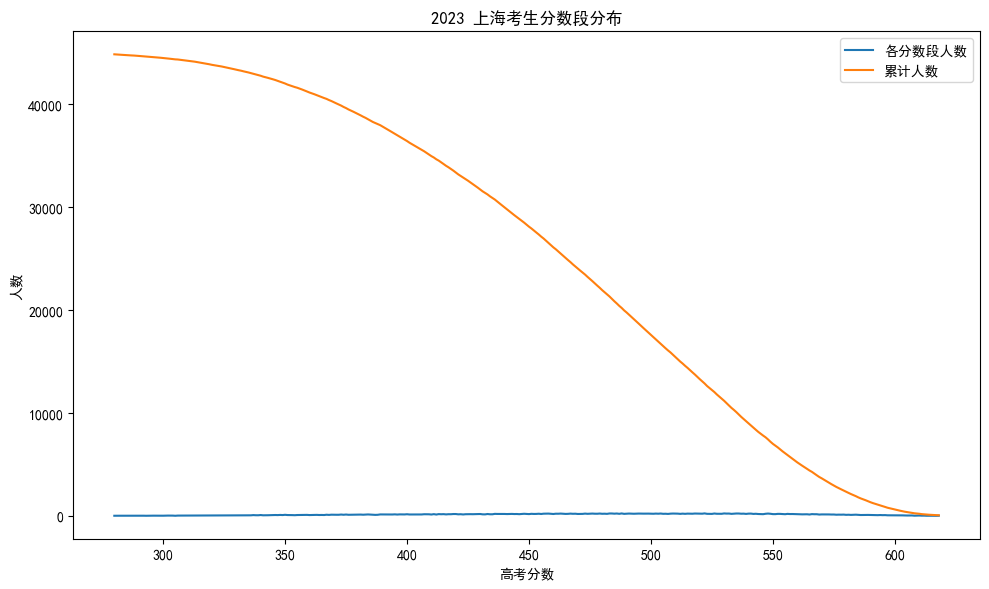

In [35]:
#分数段分布（折线 + 累计人数）
plt.figure(figsize=(10,6))
sns.lineplot(x='分数', y='人数', data=df_score, label='各分数段人数')
sns.lineplot(x='分数', y='累计人数', data=df_score, label='累计人数')
plt.title('2023 上海考生分数段分布')
plt.xlabel('高考分数')
plt.ylabel('人数')
plt.legend()
plt.tight_layout()
plt.savefig(DIR / "score_line_2023.png", dpi=300)  # ← 保存图片
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\3906561823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='批次', y='最低分', data=df_major, palette='Set3')


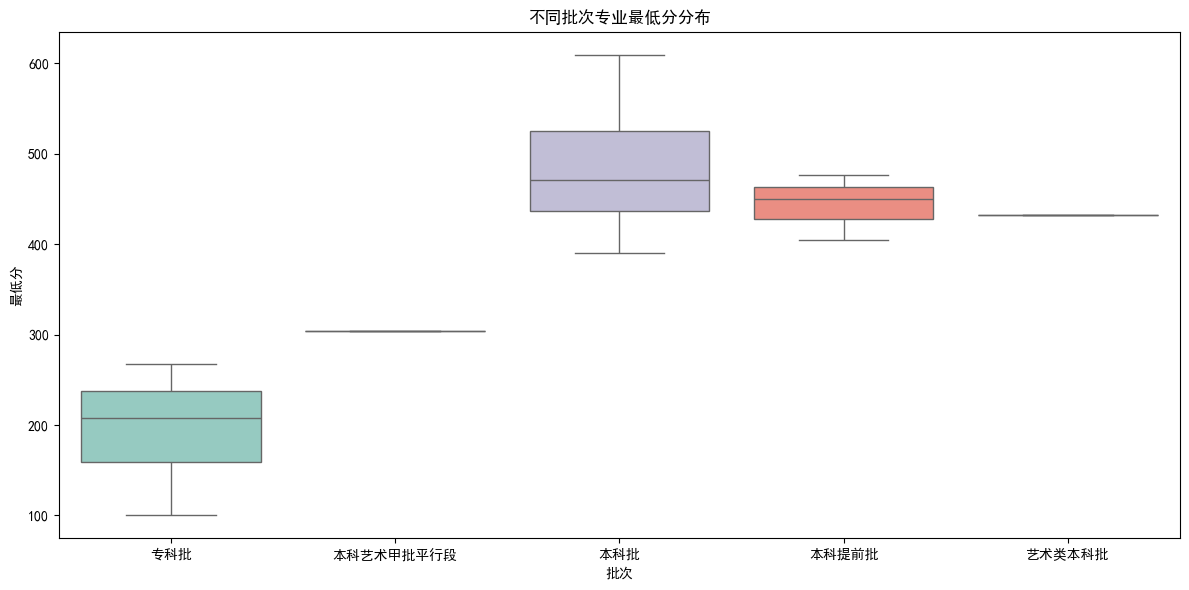

In [36]:
#专业最低分箱线图（可看整体难度水平）
plt.figure(figsize=(12,6))
sns.boxplot(x='批次', y='最低分', data=df_major, palette='Set3')
plt.title('不同批次专业最低分分布')
plt.xlabel('批次')
plt.ylabel('最低分')
plt.tight_layout()
plt.savefig(DIR / "major_box_2023.png", dpi=300)  # ← 保存图片
plt.show()


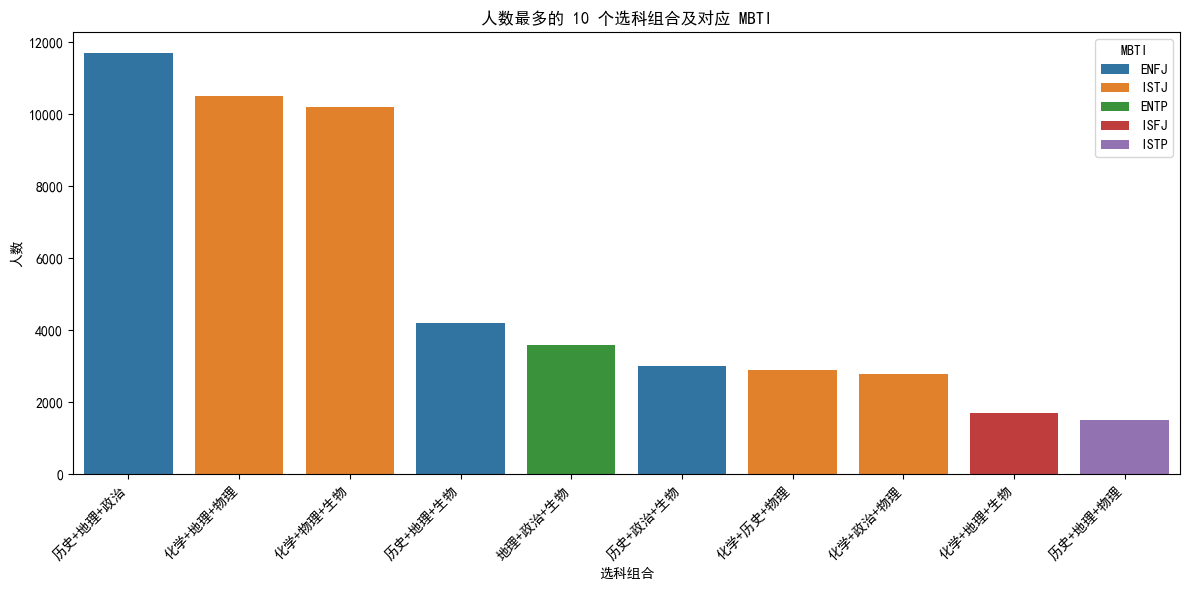

In [37]:
#选科组合 × MBTI　人数柱状图
plt.figure(figsize=(12,6))
top10 = df_combo.nlargest(10, '人数')
sns.barplot(x='选科组合', y='人数', hue='MBTI', data=top10, dodge=False)
plt.title('人数最多的 10 个选科组合及对应 MBTI')
plt.xlabel('选科组合')
plt.ylabel('人数')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DIR / "combo_mbti_bar_2023.png", dpi=300)  # ← 保存图片
plt.show()



## 步骤 3：核心算法实现与训练（LSTM 位次预测）

In [38]:
# 0. 环境与数据准备

In [39]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models, callbacks


In [40]:
# 0. 路径 & 数据加载
DIR      = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")
PATH_RANK_CLEAN = DIR / "上海一分一段_2017-2022_clean.csv"
df_rank = pd.read_csv(PATH_RANK_CLEAN, encoding="utf-8-sig")

In [41]:
# 1. 特征 & 目标
#    这里用 “分数” 预测 “percentile”（位次百分比），你也可以换成累计人数或位次
FEATURE_COLS = ["分数"]
TARGET_COL   = "percentile"

X = df_rank[FEATURE_COLS].values.astype("float32")
y = df_rank[TARGET_COL].values.astype("float32")

In [42]:
# 2. 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# 3. 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [44]:
# 4. 重塑为 LSTM 要求的 3D 张量 (samples, timesteps, features)
#    这里直接用 timesteps=1
X_train_scaled = X_train_scaled[:, None, :]
X_test_scaled  = X_test_scaled[:,  None, :]

In [45]:
# 5. 构建 LSTM 模型
n_features = X_train_scaled.shape[-1]
model = models.Sequential([
    layers.Input(shape=(1, n_features)),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # 回归输出：percentile
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# 6. 训练（带早停）
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/200
169/169 - 4s - 26ms/step - loss: 0.1740 - mae: 0.3237 - val_loss: 0.0928 - val_mae: 0.2358
Epoch 2/200
169/169 - 1s - 4ms/step - loss: 0.0957 - mae: 0.2252 - val_loss: 0.0876 - val_mae: 0.2063
Epoch 3/200
169/169 - 1s - 4ms/step - loss: 0.0928 - mae: 0.2172 - val_loss: 0.0862 - val_mae: 0.2016
Epoch 4/200
169/169 - 1s - 4ms/step - loss: 0.0929 - mae: 0.2172 - val_loss: 0.0866 - val_mae: 0.1949
Epoch 5/200
169/169 - 1s - 3ms/step - loss: 0.0920 - mae: 0.2136 - val_loss: 0.0863 - val_mae: 0.2140
Epoch 6/200
169/169 - 1s - 5ms/step - loss: 0.0921 - mae: 0.2150 - val_loss: 0.0851 - val_mae: 0.1981
Epoch 7/200
169/169 - 1s - 5ms/step - loss: 0.0916 - mae: 0.2109 - val_loss: 0.0849 - val_mae: 0.1845
Epoch 8/200
169/169 - 1s - 5ms/step - loss: 0.0912 - mae: 0.2117 - val_loss: 0.0845 - val_mae: 0.1960
Epoch 9/200
169/169 - 1s - 6ms/step - loss: 0.0909 - mae: 0.2091 - val_loss: 0.0840 - val_mae: 0.1955
Epoch 10/200
169/169 - 1s - 7ms/step - loss: 0.0903 - mae: 0.2081 - val_loss: 0.0

In [48]:
# 8. 保存模型和 scaler
MODEL_DIR = DIR / "lstm_rank_model"
MODEL_DIR.mkdir(exist_ok=True)
model.save(MODEL_DIR / "lstm_rank.h5")
pd.to_pickle(scaler, MODEL_DIR / "scaler_rank.pkl")
print(f"✔ 模型和 scaler 已保存到：{MODEL_DIR}")

✔ 模型和 scaler 已保存到：C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\lstm_rank_model


In [49]:
#可视化
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# -------- 中文字体 --------
# 1. 指定黑体字体路径（Windows自带）
font_path = "C:/Windows/Fonts/simhei.ttf"
simhei_font = font_manager.FontProperties(fname=font_path)

# 2. 全局设置字体
plt.rcParams['font.family'] = simhei_font.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示

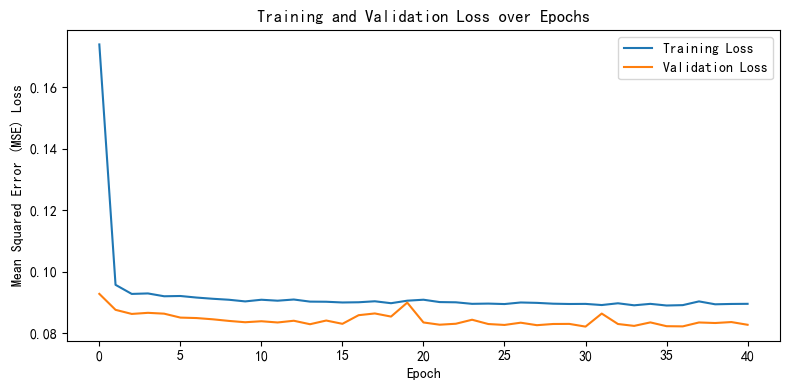

In [50]:
import matplotlib.pyplot as plt
from pathlib import Path

# Output directory
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年")
DIR.mkdir(parents=True, exist_ok=True)

# —— 1. Training & Validation Loss Curve —— 
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE) Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.savefig(DIR / "lstm_loss_curve_en.png", dpi=300)
plt.show()



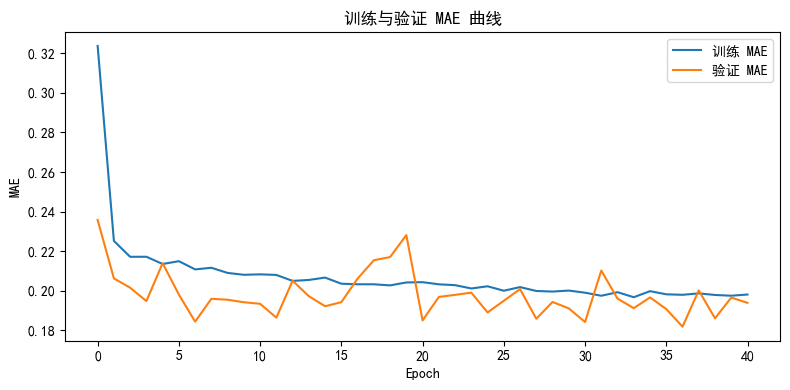

In [51]:
# —— 2. 训练 & 验证 MAE 曲线 —— 
plt.figure(figsize=(8, 4))
plt.plot(history.history['mae'], label='训练 MAE')
plt.plot(history.history['val_mae'], label='验证 MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('训练与验证 MAE 曲线')
plt.legend()
plt.tight_layout()
plt.savefig(DIR / "lstm_mae_curve.png", dpi=300)
plt.show()

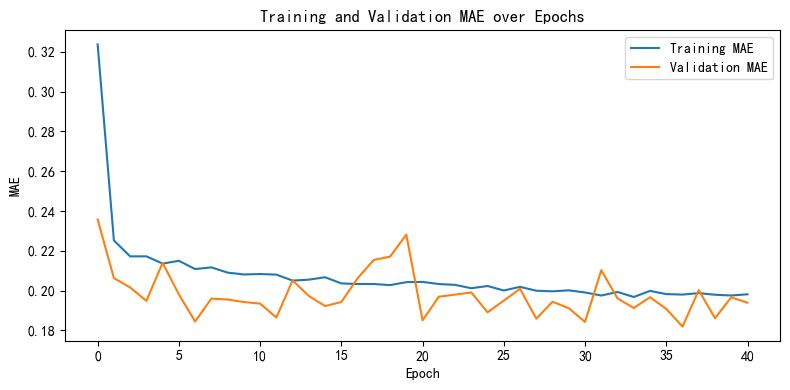

In [52]:
# —— 2. Training & Validation MAE Curve —— 
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history['mae'],      label='Training MAE')
plt.plot(history.history['val_mae'],  label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE over Epochs')
plt.legend()
plt.tight_layout()
plt.savefig(DIR / "lstm_mae_curve.png", dpi=300)
plt.show()


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


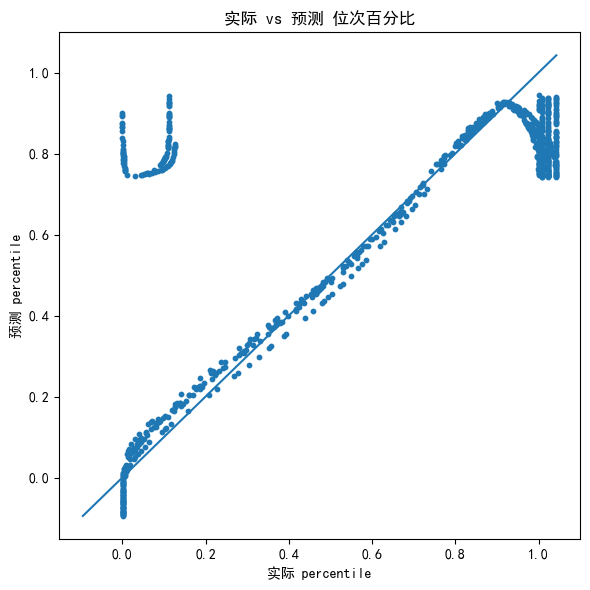

In [53]:
# —— 3. 实际 vs 预测 散点图 —— 
# 预测
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=10)
# 对角参考线
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel('实际 percentile')
plt.ylabel('预测 percentile')
plt.title('实际 vs 预测 位次百分比')
plt.tight_layout()
plt.savefig(DIR / "lstm_scatter_actual_vs_pred.png", dpi=300)
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


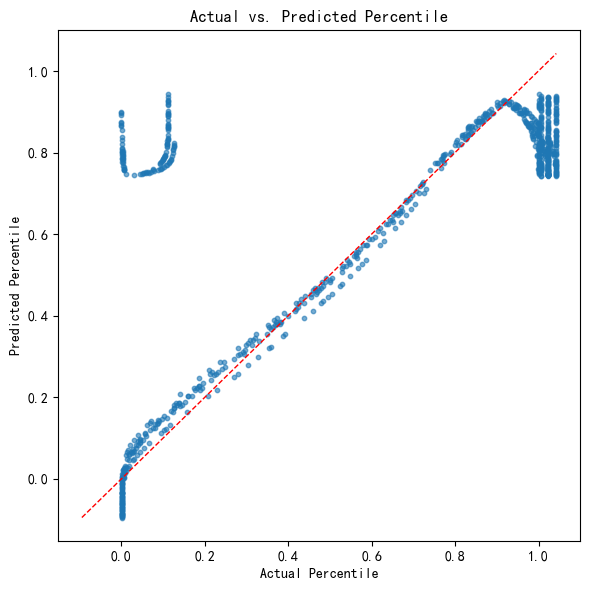

In [54]:
#  Scatter plot: Actual vs. Predicted Percentile
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=10, alpha=0.6)

#  45° reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.xlabel('Actual Percentile')
plt.ylabel('Predicted Percentile')
plt.title('Actual vs. Predicted Percentile')
plt.tight_layout()
plt.savefig(DIR / "lstm_scatter_actual_vs_pred.png", dpi=300)
plt.show()


In [55]:
from sklearn.metrics import r2_score

# —— 假设前面已经计算好了 y_pred, 并且 y_test 可用 —— 

# 4. 计算并打印 R-squared（R方值）
r_squared = r2_score(y_test, y_pred)
print(f"R-squared (R方) = {r_squared:.2f}")

print("\n✓ 数据可视化内容已添加完成。")


R-squared (R方) = 0.50

✓ 数据可视化内容已添加完成。


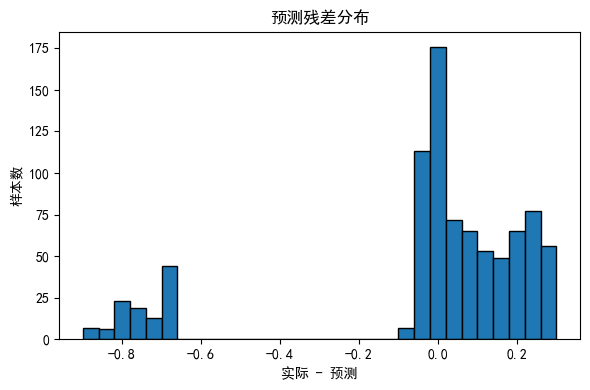

MAPE = 7342.96%


In [56]:
from sklearn.metrics import mean_absolute_percentage_error

# 残差直方图
residuals = y_test - y_pred.ravel()
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k')
plt.title('预测残差分布')
plt.xlabel('实际 - 预测')
plt.ylabel('样本数')
plt.tight_layout()
plt.show()

# MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE = {mape:.2%}")


### 优化模型

In [57]:
import pandas as pd
from pathlib import Path

# 1. 路径定义
DIR        = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")
PATH_MAJOR = DIR / "2023上海专业分数线_clean.csv"

# 2. 读取
df_major = pd.read_csv(PATH_MAJOR, encoding="utf-8-sig")

# 原始列：年份、生源地、科类、批次、院校名称、专业名称、
#         专业备注、最低分、最低位次、最高分、平均分

# 3. 去掉无关字段，只保留：
#    [年份、批次、最低分、最低位次、平均分]
df_major_clean = df_major[[
    "年份",
    "批次",
    "最低分",
    "最低位次",
    "平均分"
]].copy()

# 4. 把“批次” one-hot 或编码成数值（以下示例编码）
df_major_clean["批次_code"] = df_major_clean["批次"].astype("category").cat.codes

# 5. 确保数值列类型正确
for col in ["最低分", "最低位次", "平均分"]:
    df_major_clean[col] = pd.to_numeric(df_major_clean[col], errors="coerce")

# 6. 最终列重排序
df_major_clean = df_major_clean[[
    "年份", "批次_code", "最低分", "最低位次", "平均分"
]]

# 7. 保存或输出预览
OUT = DIR / "2023上海专业分数线_model_ready.csv"
df_major_clean.to_csv(OUT, index=False, encoding="utf-8-sig")

print(f"⇢ df_major_clean: {df_major_clean.shape} 行")
print(df_major_clean.head(3))



⇢ df_major_clean: (3524, 5) 行
     年份  批次_code  最低分    最低位次  平均分
0  2023        0  100  6003.0  138
1  2023        0  101  5997.0  153
2  2023        0  101  5997.0  199


In [58]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models, callbacks

In [59]:
# 0. 路径
DIR         = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")
PATH_RANK   = DIR / "上海一分一段_2017-2022_clean.csv"
PATH_MAJOR  = DIR / "2023上海专业分数线_model_ready.csv"


In [60]:
# 1. 读取数据
df_rank  = pd.read_csv(PATH_RANK,  encoding="utf-8-sig")
df_major = pd.read_csv(PATH_MAJOR, encoding="utf-8-sig")


In [61]:
# 2. 确保 df_major 只有 2023 年的那一行（如果 clean 表里还有其它年份可以先筛）
df_major_2023 = df_major.copy()  # 已经是 2023 年数据

In [62]:
# 3. 把专业表的数值特征“广播”到所有分数行
#    直接将那一行的特征附到 df_rank
#    （无需 on='年份'，因为始终用 2023 年数据）
for col in ["批次_code", "最低分", "最低位次", "平均分"]:
    df_rank[col] = df_major_2023[col].iloc[0]

In [63]:
# 4. 构造衍生特征
total_n = df_rank["累计人数"].max()
df_rank["score_gap"] = df_rank["分数"] - df_rank["最低分"]
df_rank["rank_abs"]  = (df_rank["percentile"] * total_n).astype(int)
df_rank["rank_gap"]  = df_rank["rank_abs"] - df_rank["最低位次"]

In [64]:
# 5. 选择特征和目标
FEATURE_COLS = [
    "分数", "本段人数", "累计人数",
    "批次_code", "最低分", "最低位次", "平均分",
    "score_gap", "rank_gap"
]
TARGET_COL = "percentile"

X = df_rank[FEATURE_COLS].astype("float32").values
y = df_rank[TARGET_COL].astype("float32").values


In [65]:
# 6. 划分、标准化、reshape
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)[:, None, :]
X_test_s  = scaler.transform(X_test)[:,  None, :]


In [66]:
# 7. 构建 & 训练 LSTM
n_feat = X_train_s.shape[-1]
model = models.Sequential([
    layers.Input(shape=(1, n_feat)),
    layers.LSTM(64),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
model.compile("adam", loss="mse", metrics=["mae"])
early = callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train_s, y_train,
    epochs=200, batch_size=16,
    validation_split=0.2,
    callbacks=[early], verbose=2
)


Epoch 1/200
169/169 - 3s - 15ms/step - loss: 0.0634 - mae: 0.1242 - val_loss: 3.5257e-04 - val_mae: 0.0133
Epoch 2/200
169/169 - 1s - 3ms/step - loss: 2.7539e-04 - mae: 0.0120 - val_loss: 2.4955e-04 - val_mae: 0.0115
Epoch 3/200
169/169 - 0s - 3ms/step - loss: 2.1183e-04 - mae: 0.0107 - val_loss: 2.0299e-04 - val_mae: 0.0103
Epoch 4/200
169/169 - 0s - 3ms/step - loss: 1.6507e-04 - mae: 0.0096 - val_loss: 1.6892e-04 - val_mae: 0.0097
Epoch 5/200
169/169 - 0s - 3ms/step - loss: 1.3079e-04 - mae: 0.0086 - val_loss: 1.2329e-04 - val_mae: 0.0082
Epoch 6/200
169/169 - 0s - 3ms/step - loss: 1.0289e-04 - mae: 0.0076 - val_loss: 1.0691e-04 - val_mae: 0.0077
Epoch 7/200
169/169 - 0s - 2ms/step - loss: 8.1911e-05 - mae: 0.0068 - val_loss: 6.6884e-05 - val_mae: 0.0063
Epoch 8/200
169/169 - 1s - 3ms/step - loss: 6.2632e-05 - mae: 0.0060 - val_loss: 5.4059e-05 - val_mae: 0.0056
Epoch 9/200
169/169 - 1s - 4ms/step - loss: 5.0224e-05 - mae: 0.0055 - val_loss: 4.3611e-05 - val_mae: 0.0051
Epoch 10/200


In [69]:
from sklearn.metrics import mean_absolute_error, r2_score

# 8. 评估
y_pred = model.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"Test MAE: {mae:.4f}")
print(f"R²      : {r2:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Test MAE: 0.0014
R²      : 1.0000


In [70]:
# 9. 保存模型与 scaler
MODEL_DIR = DIR / "lstm_rank_opt"
MODEL_DIR.mkdir(exist_ok=True)
model.save(MODEL_DIR / "lstm_rank_opt.h5")
pd.to_pickle(scaler, MODEL_DIR / "scaler_rank_opt.pkl")
print("优化后的模型与 scaler 已保存至：", MODEL_DIR)

优化后的模型与 scaler 已保存至： C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\lstm_rank_opt


In [71]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

# a) 把 LSTM 外包成一个 sklearn 可调用模型（或用简单模型做示例）
#    这里用线性回归示例，LSTM 可用 KerasClassifierWrapper / 自定义 CV
from sklearn.linear_model import LinearRegression

X_flat = X.reshape(X.shape[0], -1)  # LSTM 的 (n,1,f) → (n,f)
y      = y

# b) 5 折交叉验证：MAE 和 R²
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []
r2_scores  = []

for train_idx, test_idx in kf.split(X_flat):
    X_tr, X_te = X_flat[train_idx], X_flat[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    # 标准化
    from sklearn.preprocessing import StandardScaler
    scaler_cv = StandardScaler().fit(X_tr)
    X_tr_s = scaler_cv.transform(X_tr)
    X_te_s = scaler_cv.transform(X_te)
    
    # 训练简单模型（或你的 LSTM：在这里请用适配 CV 的方式）
    model_cv = LinearRegression().fit(X_tr_s, y_tr)
    
    # 评估
    y_pred = model_cv.predict(X_te_s)
    mae_scores.append(mean_absolute_error(y_te, y_pred))
    r2_scores.append(r2_score(y_te, y_pred))

print("5-Fold CV MAE:", np.mean(mae_scores), "±", np.std(mae_scores))
print("5-Fold CV R²:",  np.mean(r2_scores),  "±", np.std(r2_scores))


5-Fold CV MAE: 2.0384701e-07 ± 8.112089e-08
5-Fold CV R²: 1.0 ± 0.0


### 可视化

In [72]:
from pathlib import Path

# 把下面这一行替换成你本地的完整目录
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")

# 验证一下目录里到底有哪些文件
print(list(DIR.iterdir()))


[WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/2.drawio.png'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/2023上海专业分数线.txt'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/2023上海专业分数线_clean.csv'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/2023上海专业分数线_model_ready.csv'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/2023上海专业分数线_with_PredictedMBTI.csv'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/2023年考生高考成绩分布表_clean.csv'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/2023年考生高考成绩分布表（上海市）.txt'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/benchmark_models'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/combo_based_recommendations.csv'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/combo_mbti_bar_2023.png'), WindowsPath('C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/用到的/fig_mbti_pie_2023.

Time-Split Test MAE: 0.24189524625202702
Time-Split Test R² : 0.5198168966636019


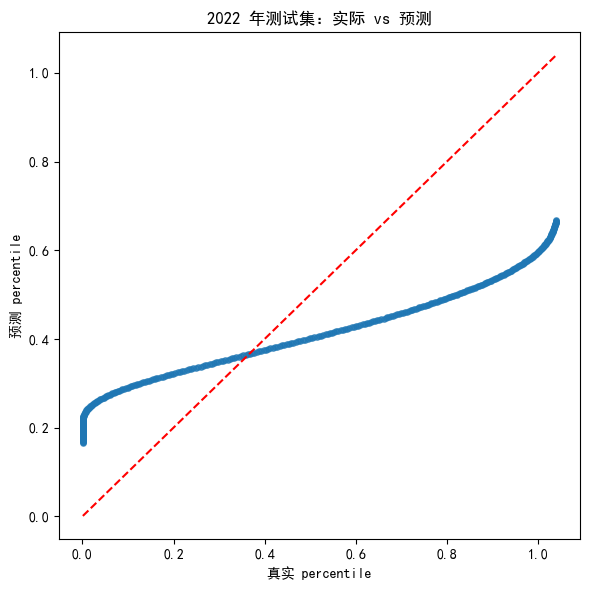

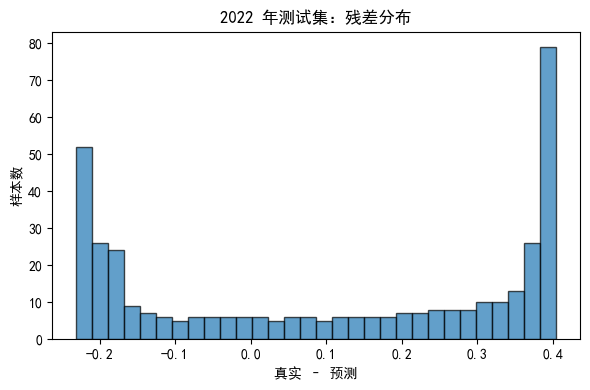

In [73]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 设定正确的目录
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")

# 2. 读取清洗后的分数分布表
df_rank = pd.read_csv(DIR / "上海一分一段_2017-2022_clean.csv", encoding="utf-8-sig")

# 3. 随后按年份做时序切分
train = df_rank[df_rank["年份"] <= 2021]
test  = df_rank[df_rank["年份"] == 2022]

X_tr = train[["分数"]].values
y_tr = train["percentile"].values
X_te = test [ ["分数"] ].values
y_te = test [ "percentile"].values

# 4. 标准化
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

# 5. 训练 & 评估
model = LinearRegression().fit(X_tr_s, y_tr)
y_pred = model.predict(X_te_s)

print("Time-Split Test MAE:", mean_absolute_error(y_te, y_pred))
print("Time-Split Test R² :",   r2_score(y_te, y_pred))

# 6. 可视化：散点图 + 残差直方图
plt.figure(figsize=(6,6))
plt.scatter(y_te, y_pred, s=15, alpha=0.7)
mn, mx = y_te.min(), y_te.max()
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('真实 percentile'); plt.ylabel('预测 percentile')
plt.title('2022 年测试集：实际 vs 预测')
plt.tight_layout()
plt.savefig(DIR / "time_split_scatter.png", dpi=300)
plt.show()

residuals = y_te - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('真实 – 预测'); plt.ylabel('样本数')
plt.title('2022 年测试集：残差分布')
plt.tight_layout()
plt.savefig(DIR / "time_split_residuals.png", dpi=300)
plt.show()


Time-Split Test MAE: 0.24189524625202702
Time-Split Test R² : 0.5198168966636019


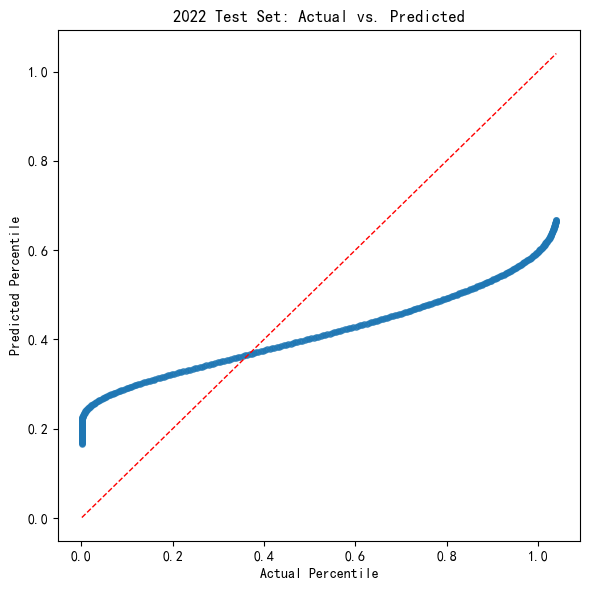

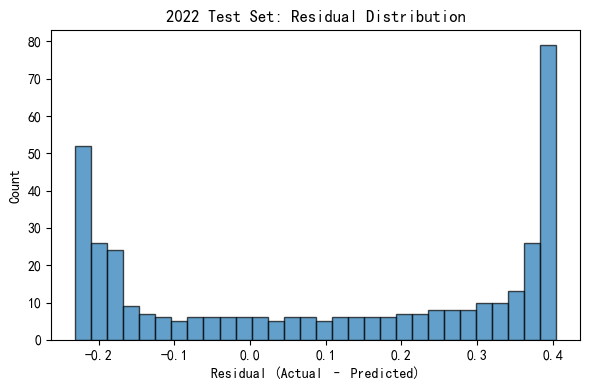

In [74]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Set the correct working directory
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")

# 2. Load the cleaned score vs. percentile data
df_rank = pd.read_csv(DIR / "上海一分一段_2017-2022_clean.csv", encoding="utf-8-sig")

# 3. Perform a time-based split by year
train = df_rank[df_rank["年份"] <= 2021]
test  = df_rank[df_rank["年份"] == 2022]

X_tr = train[["分数"]].values
y_tr = train["percentile"].values
X_te = test [ ["分数"] ].values
y_te = test [ "percentile"].values

# 4. Standardize the features
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

# 5. Train & evaluate a Linear Regression model
model  = LinearRegression().fit(X_tr_s, y_tr)
y_pred = model.predict(X_te_s)

print("Time-Split Test MAE:", mean_absolute_error(y_te, y_pred))
print("Time-Split Test R² :",   r2_score(y_te, y_pred))

# 6a. Visualization: Scatter plot of Actual vs. Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_te, y_pred, s=15, alpha=0.7)
mn, mx = y_te.min(), y_te.max()
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
plt.xlabel('Actual Percentile')
plt.ylabel('Predicted Percentile')
plt.title('2022 Test Set: Actual vs. Predicted')
plt.tight_layout()
plt.savefig(DIR / "time_split_scatter.png", dpi=300)
plt.show()

# 6b. Visualization: Residuals Histogram
residuals = y_te - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Residual (Actual – Predicted)')
plt.ylabel('Count')
plt.title('2022 Test Set: Residual Distribution')
plt.tight_layout()
plt.savefig(DIR / "time_split_residuals.png", dpi=300)
plt.show()



Time-Split Test MAE: 0.24189524625202702
Time-Split Test R² : 0.5198168966636019


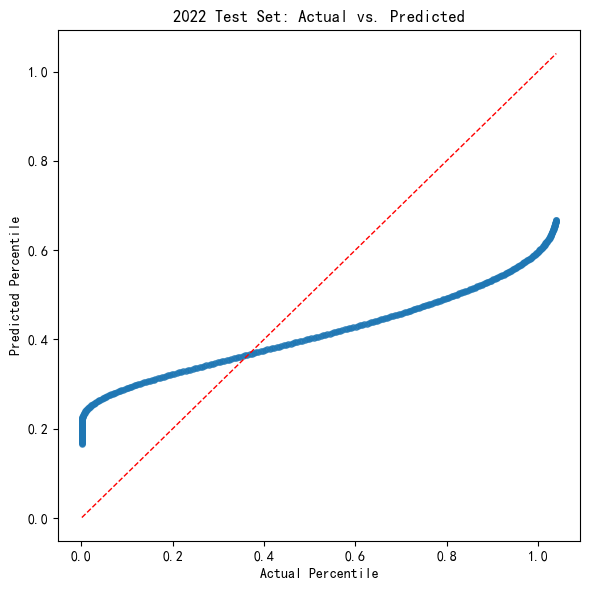

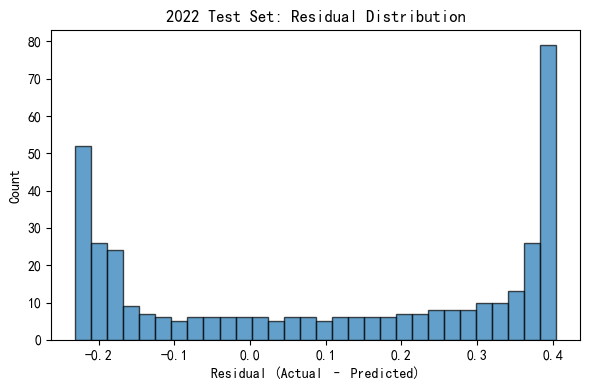

In [75]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Directories
BASE_DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年")
DATA_DIR = BASE_DIR / "用到的"
BASE_DIR.mkdir(parents=True, exist_ok=True)

# 2. Load the cleaned score vs. percentile data from the “用到的” folder
df_rank = pd.read_csv(
    DATA_DIR / "上海一分一段_2017-2022_clean.csv",
    encoding="utf-8-sig"
)

# 3. Time‑based split by year
train = df_rank[df_rank["年份"] <= 2021]
test  = df_rank[df_rank["年份"] == 2022]

X_tr = train[["分数"]].values
y_tr = train["percentile"].values
X_te = test [ ["分数"] ].values
y_te = test [ "percentile"].values

# 4. Standardize
scaler  = StandardScaler().fit(X_tr)
X_tr_s  = scaler.transform(X_tr)
X_te_s  = scaler.transform(X_te)

# 5. Train & evaluate linear regression
model   = LinearRegression().fit(X_tr_s, y_tr)
y_pred  = model.predict(X_te_s)

print("Time-Split Test MAE:", mean_absolute_error(y_te, y_pred))
print("Time-Split Test R² :",   r2_score(y_te, y_pred))

# 6a. Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_te, y_pred, s=15, alpha=0.7)
mn, mx = y_te.min(), y_te.max()
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
plt.xlabel('Actual Percentile')
plt.ylabel('Predicted Percentile')
plt.title('2022 Test Set: Actual vs. Predicted')
plt.tight_layout()
plt.savefig(BASE_DIR / "time_split_scatter.png", dpi=300)
plt.show()

# 6b. Residuals histogram
residuals = y_te - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Residual (Actual – Predicted)')
plt.ylabel('Count')
plt.title('2022 Test Set: Residual Distribution')
plt.tight_layout()
plt.savefig(BASE_DIR / "time_split_residuals.png", dpi=300)
plt.show()


In [76]:
from pathlib import Path
import pandas as pd

# 1. 把 DIR 改成你本地的完整目录
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")

# 2. 读取清洗后的分数分布表
df_rank = pd.read_csv(DIR / "上海一分一段_2017-2022_clean.csv", encoding="utf-8-sig")

# 3. 读取 2023 专业分数线特征
df_major = pd.read_csv(DIR / "2023上海专业分数线_model_ready.csv", encoding="utf-8-sig")

# 确认都加载成功
print(df_rank.shape, df_major.shape)


(4224, 5) (3524, 5)


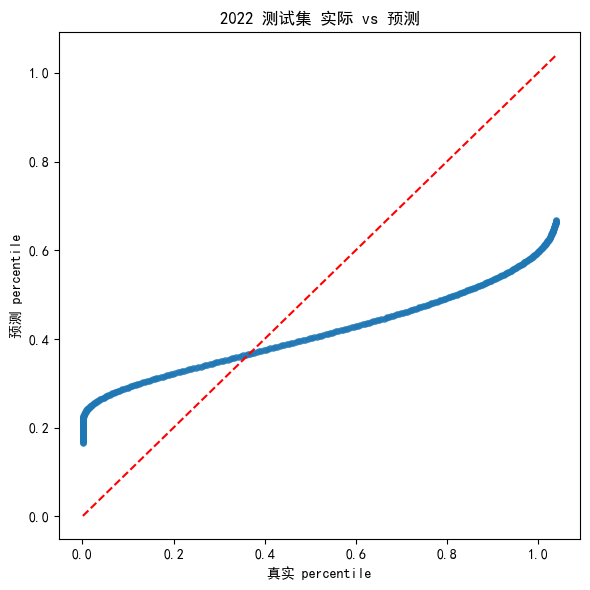

In [77]:
# 时序切分
train = df_rank[df_rank["年份"] <= 2021]
test  = df_rank[df_rank["年份"] == 2022]

# 特征与目标
FEATURE_COLS = ["分数"]
X_train = train[FEATURE_COLS].values.reshape(-1,1)
y_train = train["percentile"].values
X_test  = test [FEATURE_COLS].values.reshape(-1,1)
y_test  = test ["percentile"].values

# 标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# 训练最简单模型做演示
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

# 可视化：散点图
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=15, alpha=0.7)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv,maxv], [minv,maxv], 'r--')
plt.xlabel('真实 percentile')
plt.ylabel('预测 percentile')
plt.title('2022 测试集 实际 vs 预测')
plt.tight_layout()
plt.savefig(DIR / "time_split_scatter.png", dpi=300)
plt.show()


## 4处理大学专业对应的mbti类型

In [78]:
import pandas as pd
from pathlib import Path
import re

# 0. 路径
DIR      = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")
IN_FILE  = DIR / "2023上海专业分数线_clean.csv"
OUT_FILE = DIR / "2023上海专业分数线_with_PredictedMBTI.csv"

# 1. 读取
df = pd.read_csv(IN_FILE, encoding="utf-8-sig")

# 2. 拿到所有唯一专业名称，方便检查
unique_majors = sorted(df["专业名称"].unique())

# 3. 定义关键词 → MBTI 映射（可按需增删）
#    注意：顺序重要，会从上到下依次匹配
keyword_mbti = [
    (r"机械|制造|设计",      "ISTJ"),
    (r"体育",               "ESFJ"),
    (r"护理|临床医学|公共卫生", "ESFJ"),
    (r"计算机|软件|信息",    "INTJ"),
    (r"电子商务|财务会计|物流|经济贸易|金融|工商管理|市场|会计|财务", "ESTJ"),
    (r"建筑|土建|市政|工程管理|园林|测绘|市政|资源勘查|水利|轨道|公路|铁路", "ESTP"),
    (r"自动化|电气|电子|通信|集成电路|能源动力|电力|控制", "INTP"),
    (r"旅游|酒店|餐饮|文化服务|艺术设计", "ESFP"),
    (r"教育|外国语言|新闻传播|文科试验班|社会|公共管理", "ENFJ"),
    (r"法学|法律|法务|司法",   "ENTJ"),
    (r"生物|药学|中医药|林业|农业|畜牧业|海洋|生物技术|生命科学", "INFJ"),
    (r"医学技术|康复|护理学|口腔医学|健康管理", "ISFJ"),
    # 你可以在这里继续添加……
]

# 4. 批量预测函数
def predict_mbti(major_name):
    for pattern, mbti in keyword_mbti:
        if re.search(pattern, major_name):
            return mbti
    return None

# 5. 应用映射
df["Predicted_MBTI"] = df["专业名称"].apply(predict_mbti)

# 6. 输出哪些专业还没被映射到（Predicted_MBTI isnull）——方便补关键词
unmapped = df.loc[df["Predicted_MBTI"].isnull(), "专业名称"].unique()
print("⚠️ 以下专业未被映射到 MBTI，请补充关键词：")
for m in unmapped:
    print(" -", m)
print(f"\n共 {len(unmapped)} 个未映射专业。")

# 7. 对于未映射的，你可以先给个默认值，例如 'ISTJ'
df["Predicted_MBTI"].fillna("ISTJ", inplace=True)

# 8. 保存新表
df.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
print(f"\n✅ 已输出带 MBTI 的文件：{OUT_FILE}")


⚠️ 以下专业未被映射到 MBTI，请补充关键词：
 - 房地产类
 - 广播影视类
 - 公共事业类
 - 语言类
 - 化工技术类
 - 铁道运输类
 - 航空运输类
 - 公共服务类
 - 水上运输类
 - 非金属材料类
 - 道路运输类
 - 新闻出版类
 - 食品类
 - 安全防范类
 - 药品与医疗器械类
 - 航空装备类
 - 包装类
 - 印刷类
 - 安全类
 - 表演艺术类
 - 环境保护类
 - 眼视光类
 - 音乐与舞蹈学类
 - 经济学类
 - 中国语言文学类
 - 管理科学与工程类
 - 马克思主义理论类
 - 经济与贸易类
 - 公安学类
 - 财政学类
 - 土木类
 - 工业工程类
 - 环境科学与工程类
 - 植物生产类
 - 物理学类
 - 化工与制药类
 - 仪器类
 - 数学类
 - 纺织类
 - 轻工类
 - 化学类
 - 材料类
 - 交通运输类
 - 统计学类
 - 心理学类
 - 历史学类
 - 安全科学与工程类
 - 中西医结合类
 - 地理科学类
 - 中医学类
 - 矿业类
 - 航空航天类
 - 大气科学类
 - 食品科学与工程类
 - 民族学类
 - 兵器类
 - 力学类
 - 动物生产类
 - 水产类
 - 林学类
 - 政治学类
 - 公安技术类
 - 动物医学类
 - 工科试验班
 - 法医学类
 - 核工程类
 - 基础医学类
 - 哲学类
 - 戏剧与影视学类
 - 艺术学理论类
 - 经济管理试验班
 - 图书情报与档案管理类
 - 美术学类
 - 理科试验班
 - 理科试验班类
 - 人文科学试验班
 - 草学类
 - 工科试验班类
 - 自然科学试验班
 - 技术科学试验班

共 80 个未映射专业。

✅ 已输出带 MBTI 的文件：C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\2023上海专业分数线_with_PredictedMBTI.csv


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\854310917.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Predicted_MBTI"].fillna("ISTJ", inplace=True)


## 协同过滤兴趣/院校推荐

In [79]:
import pandas as pd, numpy as np, json
from pathlib import Path
from surprise import Dataset, Reader, SVD



In [80]:

# ---------- 1. 路径 ----------
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")


In [81]:
# ---------- 2. 读取 4 个 CSV ----------
df_combo = pd.read_csv(DIR/"subject_combo_to_mbti_clean.csv", encoding="utf-8-sig")
df_combo = df_combo.rename(columns={"选科组合":"combo", "人数":"count"})  # 标准化列名

In [82]:
df_items = pd.read_csv(DIR/"2023上海专业分数线_with_PredictedMBTI.csv", encoding="utf-8-sig")
df_items["school_major"] = df_items["院校名称"] + "_" + df_items["专业名称"]

In [83]:
# ---------- 3. 学生(pseudo-user) 画像 ----------
df_users = df_combo[["combo","MBTI","count"]].copy()
df_users["uid"] = "u_" + df_users.index.astype(str)


In [84]:
# ---------- 4. 构造 MBTI 匹配度函数 ----------
def mbti_weight(stu_mbti, maj_mbti):
    if stu_mbti == maj_mbti:           # 完全一致
        return 1.0
    if stu_mbti[:2] == maj_mbti[:2]:   # 中间两位相同（NT/NF/ST/SF）
        return 0.5
    return 0.0

In [85]:
# ---------- 5. 生成伪评分表 ----------
cand = df_users.merge(df_items, how="cross")


In [86]:
# 假设 cand["批次"] 里可能有：本科批、专科批、提前批、本科提前批……
print("批次类别:", cand["批次"].unique())

# ① 自定义批次→难度编码（本科批=3, 专科批=1, 提前批=4 等，可根据实际调整）
batch_difficulty = {
    "专科批": 1,
    "本科批": 3,
    "本科提前批": 4,
    "高职提前批": 2,
    # ... 可添加其它
}

cand["difficulty"] = cand["批次"].map(batch_difficulty)
# 万一有空的，直接补平均
cand["difficulty"] = cand["difficulty"].fillna(np.mean(list(batch_difficulty.values())))
cand["difficulty"] = cand["difficulty"] / cand["difficulty"].max()  # 归一化


批次类别: ['专科批' '本科艺术甲批平行段' '本科批' '本科提前批' '艺术类本科批']


In [87]:
# 5-B) MBTI 兴趣权重
cand["mbti_w"] = cand.apply(lambda r: mbti_weight(r["MBTI"], r["Predicted_MBTI"]), axis=1)

# 5-C) 伪评分
raw_score       = cand["mbti_w"] * (1 - cand["difficulty"])
cand["rating"]  = (raw_score * 4 + 1).clip(1,5)


In [88]:
# ---------- 6. Surprise-SVD 分解 ----------
reader  = Reader(rating_scale=(1,5))
data    = Dataset.load_from_df(cand[["uid","school_major","rating"]], reader)
trainset= data.build_full_trainset()

algo = SVD(n_factors=64, n_epochs=25, random_state=42)
algo.fit(trainset)

In [89]:
# ---------- 7. Top-N 推荐函数 ----------
def recommend(uid:str, N:int=10):
    items = df_items["school_major"].unique()
    preds = [algo.predict(uid, itm) for itm in items]
    preds.sort(key=lambda p: p.est, reverse=True)
    return [(p.iid, round(p.est,3)) for p in preds[:N]]

In [90]:
# ---------- 8. 批量输出每个选科组合的 Top-10 ----------
all_recs = []
for uid in df_users["uid"]:
    top10 = recommend(uid, 10)
    for rank,(itm,score) in enumerate(top10,1):
        all_recs.append([uid, rank, itm, score])

out = pd.DataFrame(all_recs,
                   columns=["uid","rank","school_major","est_score"])
out.to_csv(DIR/"combo_based_recommendations.csv",
           index=False, encoding="utf-8-sig")
print("✅ 推荐结果已保存 → combo_based_recommendations.csv")


✅ 推荐结果已保存 → combo_based_recommendations.csv


In [91]:
# ---------- 9. 查看示例 ----------
print(out.head(20))

    uid  rank          school_major  est_score
0   u_0     1      重庆城市管理职业学院_公共事业类      3.437
1   u_0     2        上海思博职业技术学院_语言类      3.417
2   u_0     3      上海济光职业技术学院_建筑设计类      3.414
3   u_0     4    湖南高速铁路职业技术学院_铁道运输类      3.406
4   u_0     5     上海工商外国语职业学院_广播影视类      3.403
5   u_0     6      上海现代化工职业学院_化工技术类      3.401
6   u_0     7     上海建设管理职业技术学院_房地产类      3.399
7   u_0     8     上海现代化工职业学院_非金属材料类      3.394
8   u_0     9      上海工商职业技术学院_航空运输类      3.391
9   u_0    10  天津城市建设管理职业技术学院_汽车制造类      3.386
10  u_1     1        上海思博职业技术学院_语言类      2.492
11  u_1     2      重庆城市管理职业学院_公共事业类      2.491
12  u_1     3     上海工商外国语职业学院_广播影视类      2.481
13  u_1     4      上海济光职业技术学院_建筑设计类      2.477
14  u_1     5   上海工商外国语职业学院_机械设计制造类      2.477
15  u_1     6        上海震旦职业学院_广播影视类      2.476
16  u_1     7  天津城市建设管理职业技术学院_汽车制造类      2.474
17  u_1     8      上海工商职业技术学院_航空运输类      2.469
18  u_1     9        上海旅游高等专科学校_语言类      2.469
19  u_1    10       上海工商外国语职业学院_语言类      2.465


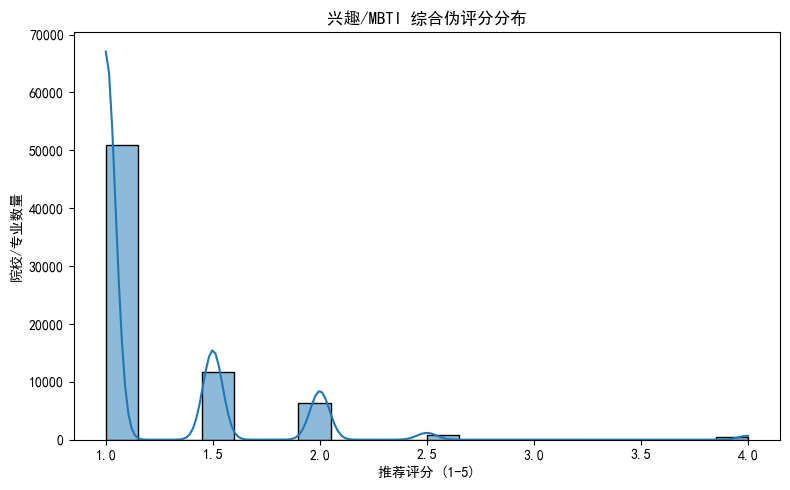

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(cand['rating'], bins=20, kde=True)
plt.title('兴趣/MBTI 综合伪评分分布')
plt.xlabel('推荐评分 (1-5)')
plt.ylabel('院校/专业数量')
plt.tight_layout()
plt.show()


In [93]:
# 假设 uid = 某个选科组合/MBTI
top_n = cand.sort_values('rating', ascending=False).head(6)
print(top_n[['院校名称','专业名称','批次','rating','Predicted_MBTI']])


              院校名称      专业名称   批次  rating Predicted_MBTI
0      上海工商外国语职业学院   机械设计制造类  专科批     4.0           ISTJ
14404     上海城建职业学院     建筑设计类  专科批     4.0           ISTJ
7371      上海城建职业学院       食品类  专科批     4.0           ISTJ
7376       上海健康医学院      眼视光类  专科批     4.0           ISTJ
7377       上海健康医学院  药品与医疗器械类  专科批     4.0           ISTJ
7379      上海第二工业大学   机械设计制造类  专科批     4.0           ISTJ


In [94]:
df_top6 = df_top6[['院校名称', '专业名称', '批次', 'est_score', 'Predicted_MBTI']] \
            .sort_values('est_score', ascending=False)
print(df_top6.to_string(index=False))

NameError: name 'df_top6' is not defined

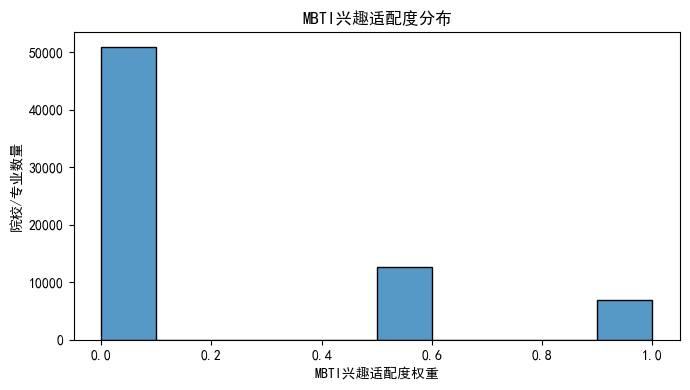

In [95]:
plt.figure(figsize=(7, 4))
sns.histplot(cand['mbti_w'], bins=10)
plt.title('MBTI兴趣适配度分布')
plt.xlabel('MBTI兴趣适配度权重')
plt.ylabel('院校/专业数量')
plt.tight_layout()
plt.show()


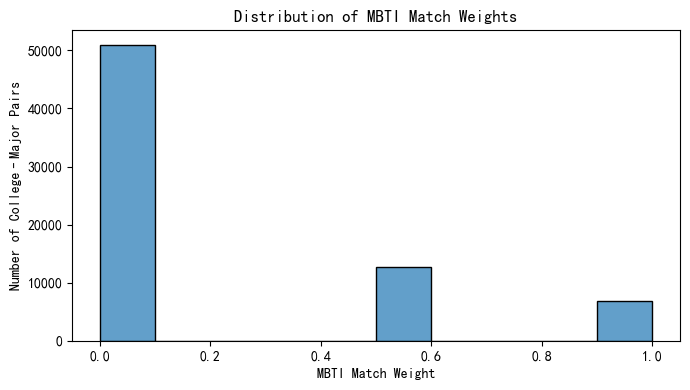

Figure saved to: C:\Users\Lenovo\Desktop\志愿填报辅助系统\mbti_match_weight_distribution.png


In [96]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the output directory exists
out_dir = r"C:\Users\Lenovo\Desktop\志愿填报辅助系统"
os.makedirs(out_dir, exist_ok=True)

# Plot
plt.figure(figsize=(7, 4))
sns.histplot(cand['mbti_w'], bins=10, edgecolor='k', alpha=0.7)
plt.title('Distribution of MBTI Match Weights')
plt.xlabel('MBTI Match Weight')
plt.ylabel('Number of College–Major Pairs')
plt.tight_layout()

# Save
output_path = os.path.join(out_dir, "mbti_match_weight_distribution.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Figure saved to: {output_path}")


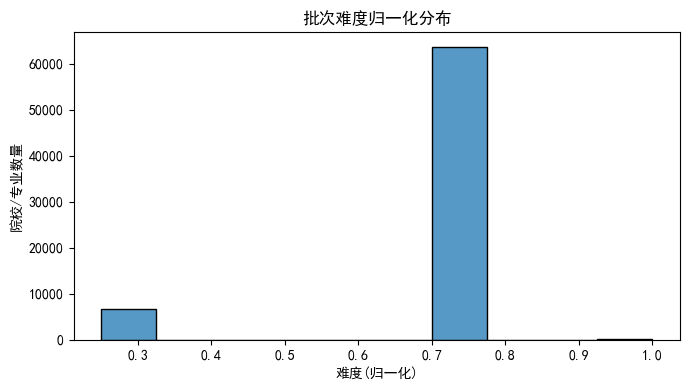

In [97]:
plt.figure(figsize=(7, 4))
sns.histplot(cand['difficulty'], bins=10)
plt.title('批次难度归一化分布')
plt.xlabel('难度(归一化)')
plt.ylabel('院校/专业数量')
plt.tight_layout()
plt.show()


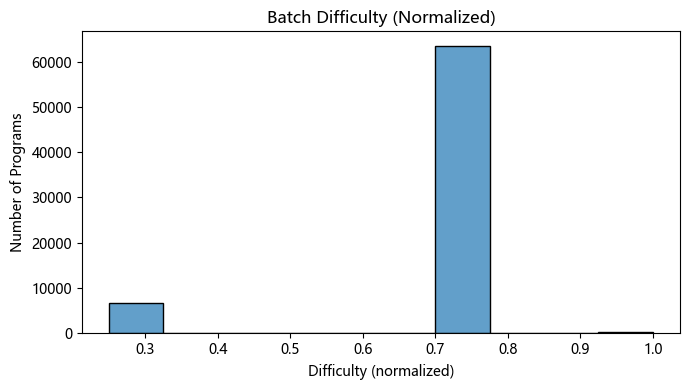

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Use a Unicode‑rich font
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 4))
sns.histplot(cand['difficulty'], bins=10, edgecolor='k', alpha=0.7)
plt.title('Batch Difficulty (Normalized)')
plt.xlabel('Difficulty (normalized)')
plt.ylabel('Number of Programs')
plt.tight_layout()

out_dir = r"C:\Users\Lenovo\Desktop\志愿填报辅助系统"
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, "difficulty_distribution.png"), dpi=300)
plt.show()


## 用 LightGBM 树模型 代替 SVD 最终打分，并用 SHAP 分析（你也可以选 sklearn 的 DecisionTreeRegressor、RandomForestRegressor 等）。

In [99]:
import pandas as pd
import numpy as np

# 假设 cand 已经在前面构造好了，并包含列：mbti_w, difficulty, rating
# 例如：
# cand = pd.read_csv("combo_based_recommendations_input.csv")

from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

# ---------- 1. 特征和目标 ----------
FEATURES = ["mbti_w", "difficulty"]  # 如果后面补上 gap，再加进来
X = cand[FEATURES]
y = cand["rating"]

# ---------- 2. 随机森林模型训练 ----------
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X, y)

# ---------- 3. SHAP 分析 ----------
# Create a TreeExplainer and compute SHAP values
explainer   = shap.Explainer(model, X)
shap_values = explainer(X)




 99%|===================| 69636/70480 [00:52<00:00]        

100%|===================| 70166/70480 [01:00<00:00]        

base_values shape: (70480,)
values shape      : (70480, 2)
feature names     : ['mbti_w', 'difficulty']


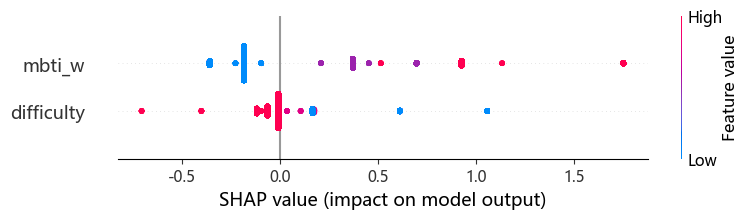

Sample 0 base value: 1.1950000000000003
Sample 0 shap values: [1.74999995 1.05499996]


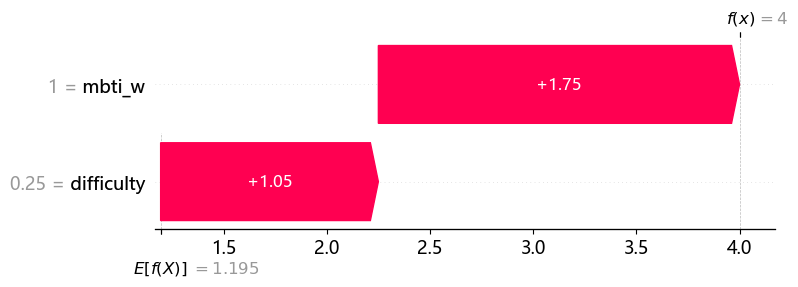

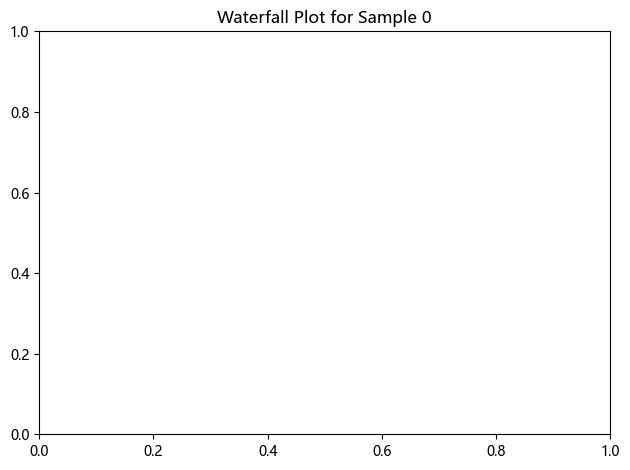

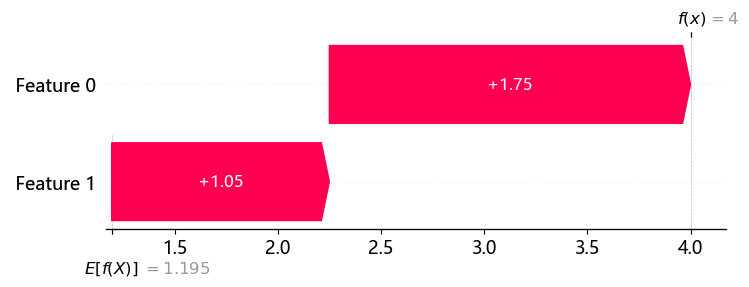

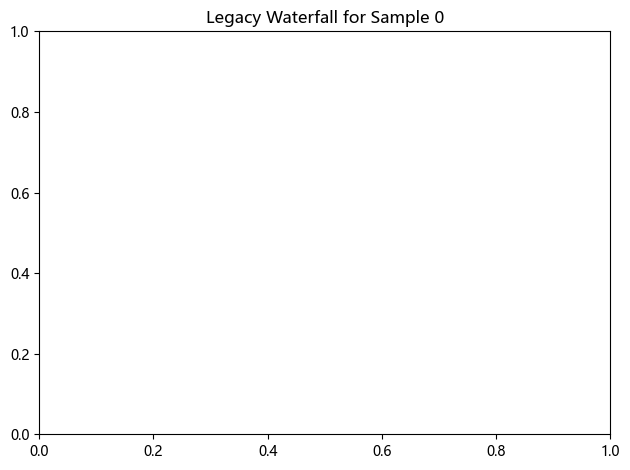

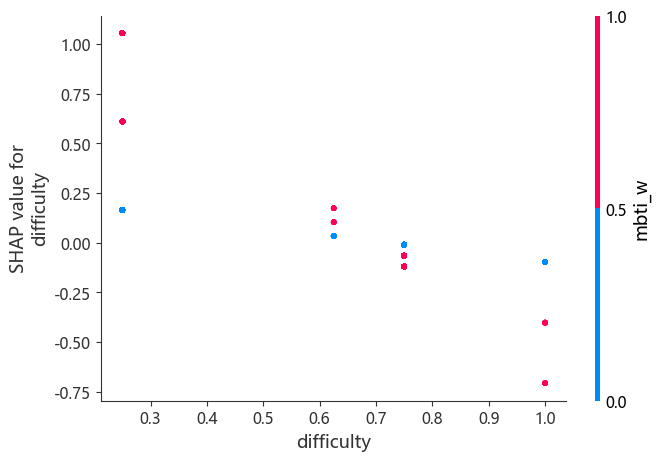

In [100]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ===（假设 cand 已经定义好）===
# cand = pd.read_csv("combo_based_recommendations_input.csv")
# 它包含列：mbti_w, difficulty, rating

FEATURES = ["mbti_w", "difficulty"]
X = cand[FEATURES]
y = cand["rating"]

# 1. 训练随机森林回归模型
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X, y)

# 2. 用统一 API 创建 Explainer 并计算 SHAP 值
explainer = shap.Explainer(model, X)   # 默认会选择 TreeExplainer
shap_values = explainer(X)

# 3. 检查基础形状
print("base_values shape:", shap_values.base_values.shape)  # (n_samples,)
print("values shape      :", shap_values.values.shape)      # (n_samples, 2)
print("feature names     :", shap_values.feature_names)     # ['mbti_w', 'difficulty']

# 4. 全局 summary plot
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X, feature_names=FEATURES)

# 5. 局部解释：Waterfall Plot，示例第 0 个样本
i = 0
base_i      = shap_values.base_values[i]   # 标量
shap_vals_i = shap_values.values[i]        # (2,)

print(f"Sample {i} base value:", base_i)
print(f"Sample {i} shap values:", shap_vals_i)

plt.figure(figsize=(6,4))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals_i,
        base_values=base_i,
        data=X.iloc[i].values,    # 如果 X 是 DataFrame
        feature_names=FEATURES
    )
)
plt.title(f"Waterfall Plot for Sample {i}")
plt.tight_layout()
plt.show()

# 6. （可选） 使用 legacy waterfall
plt.figure(figsize=(6,4))
shap.plots._waterfall.waterfall_legacy(
    base_i,
    shap_vals_i,
    FEATURES
)
plt.title(f"Legacy Waterfall for Sample {i}")
plt.tight_layout()
plt.show()

# 7. （可选） Partial Dependence / 依赖图
shap.dependence_plot(
    "difficulty", 
    shap_values.values,
    X,
    feature_names=FEATURES
)


 98%|===================| 68890/70480 [00:51<00:01]        

base_values shape: (70480,)
values shape      : (70480, 2)
feature names     : ['mbti_w', 'difficulty']


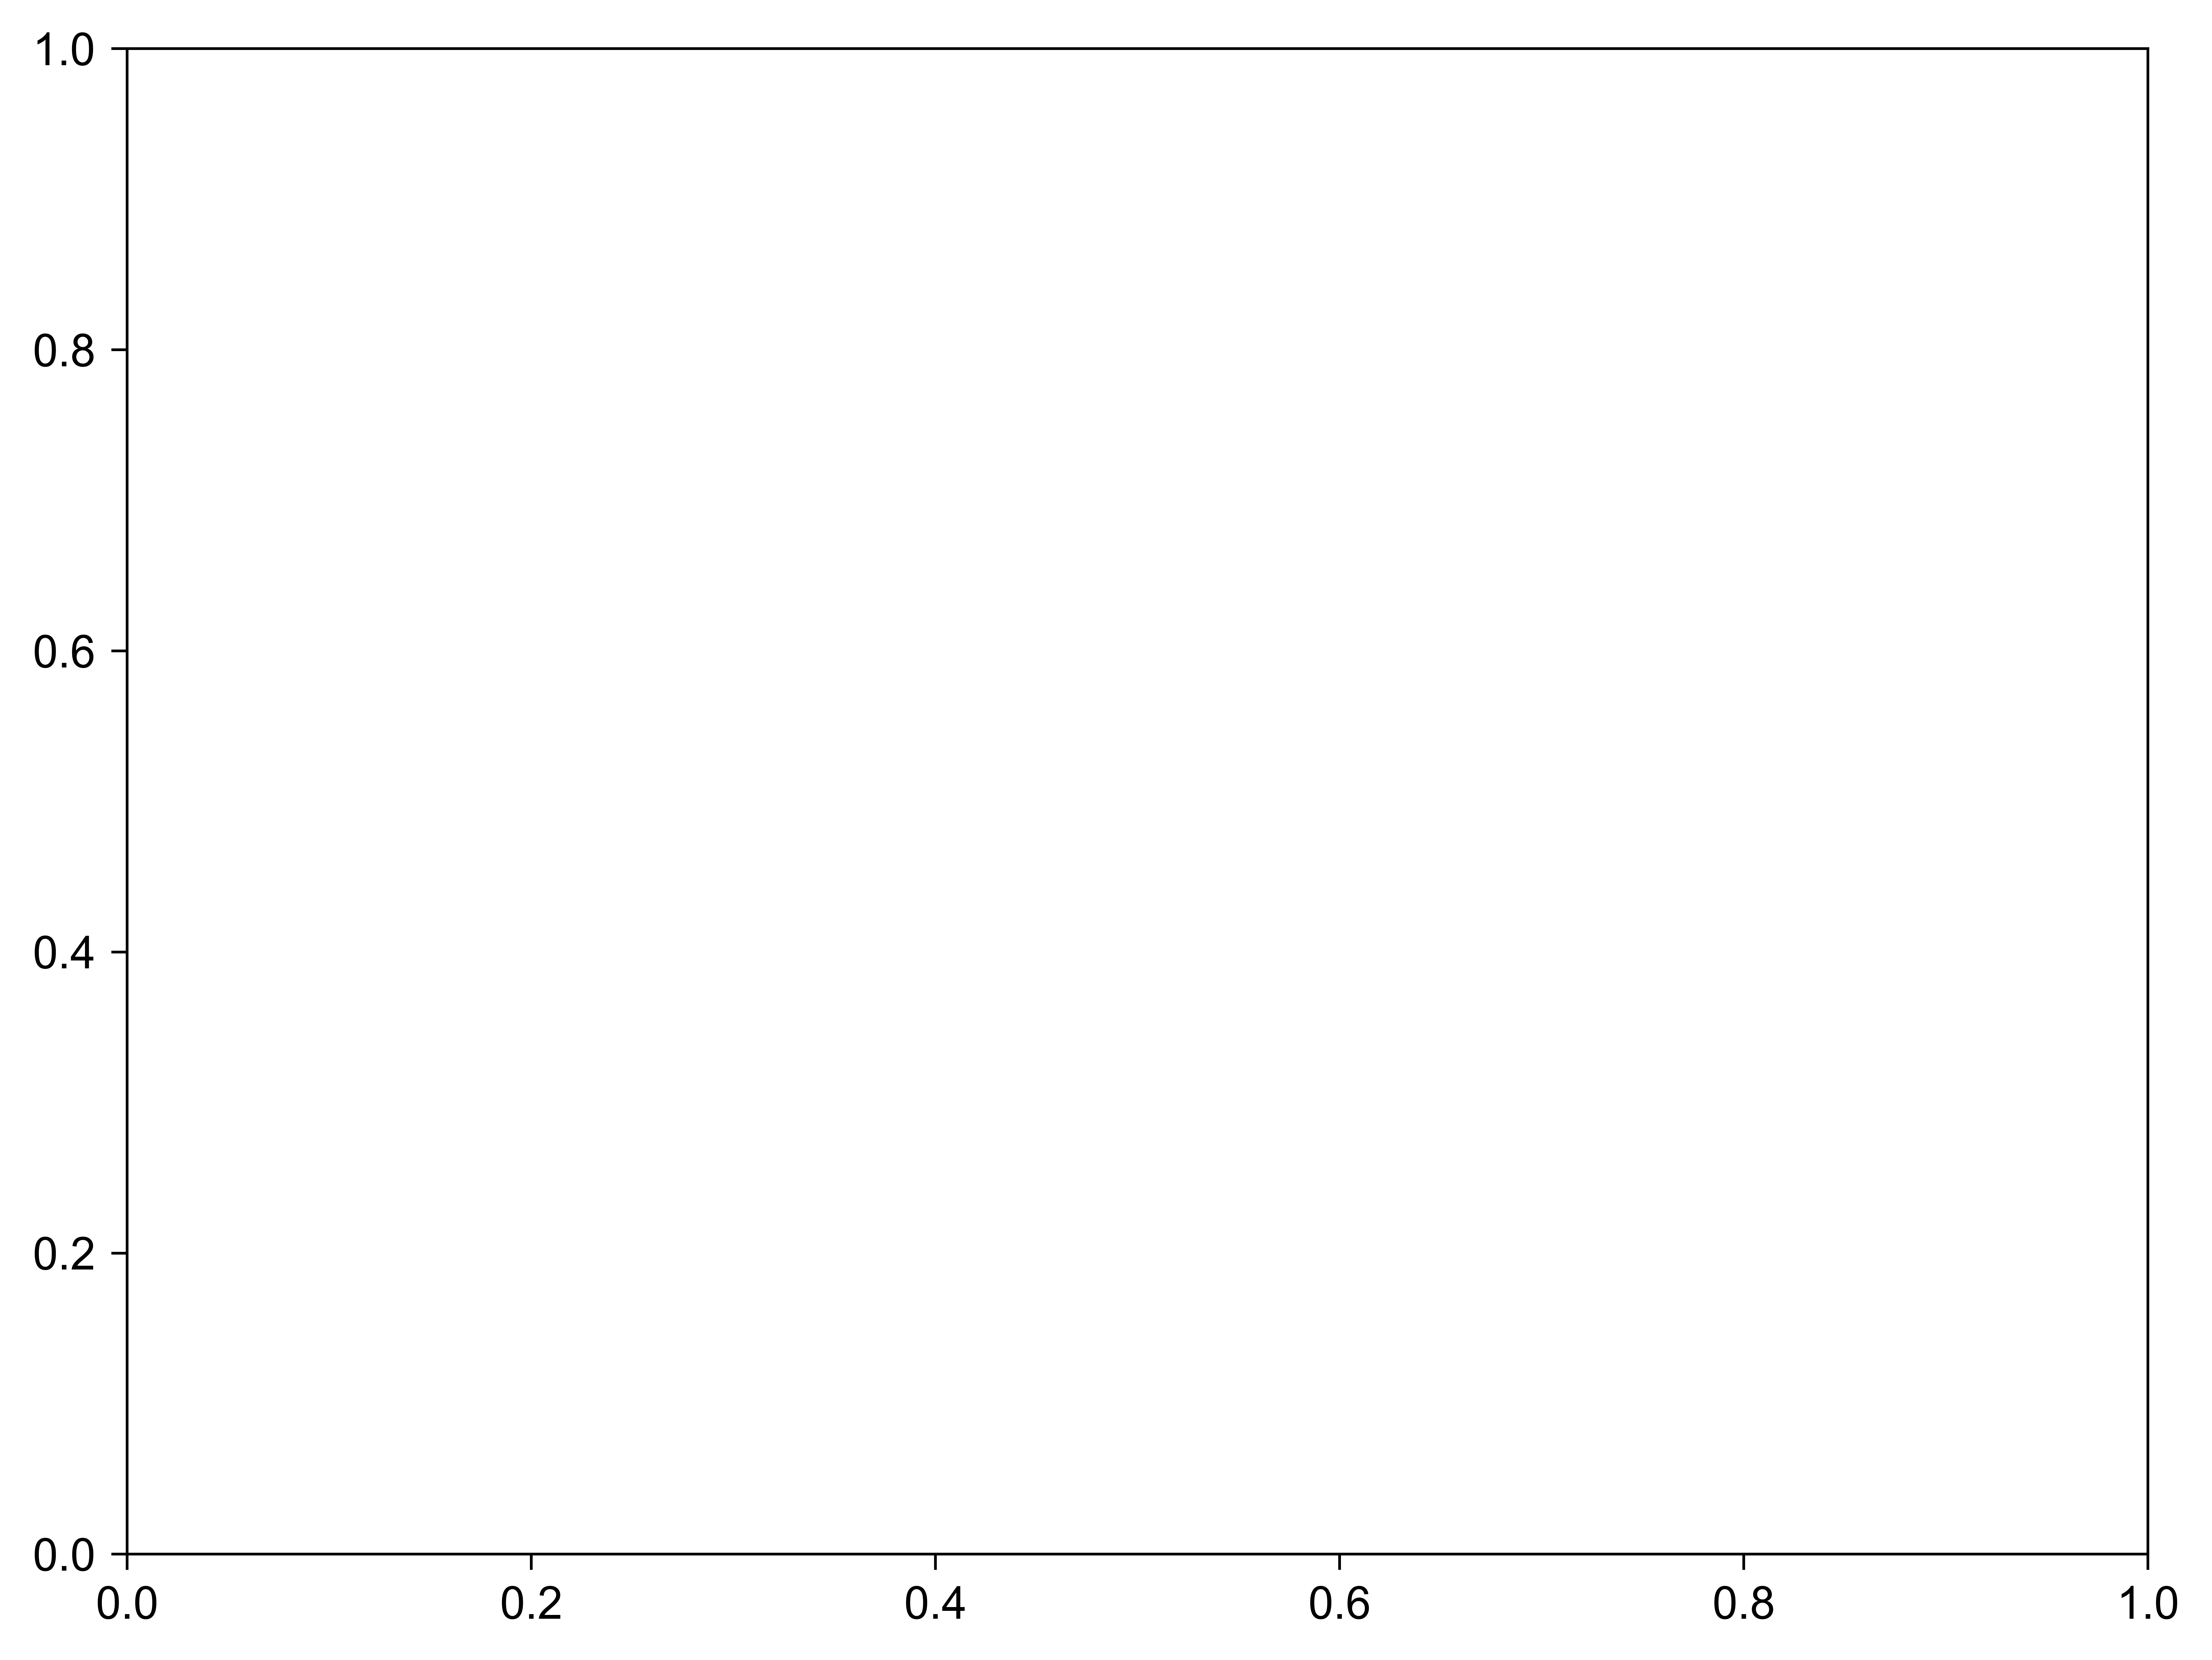

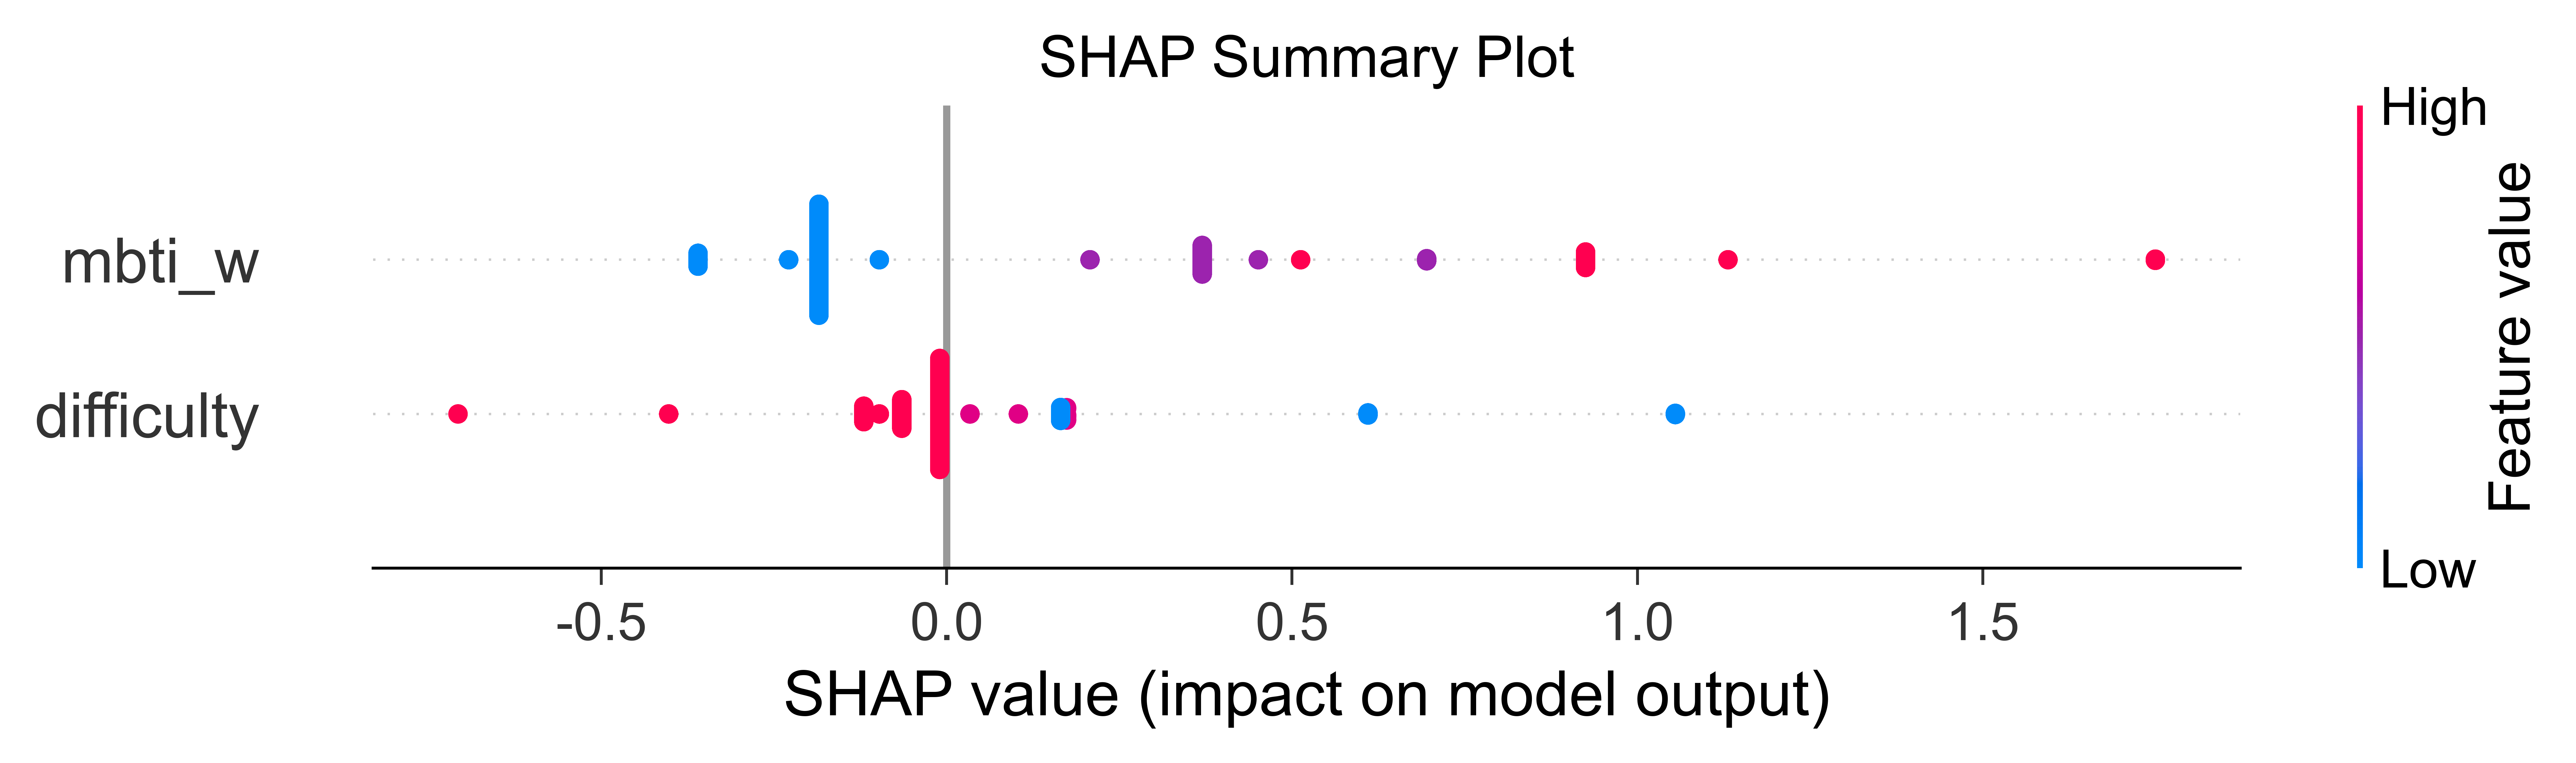

Sample 0 base value: 1.1950000000000003
Sample 0 SHAP values: [1.74999995 1.05499996]


TypeError: waterfall() got an unexpected keyword argument 'ax'

In [126]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# === assume cand is already loaded ===
# cand = pd.read_csv("combo_based_recommendations_input.csv")
# contains columns: mbti_w, difficulty, rating

FEATURES = ["mbti_w", "difficulty"]
X = cand[FEATURES]
y = cand["rating"]

# === 0) Global matplotlib style ===
plt.rcParams.update({
    'figure.dpi':        1200,     # bitmap resolution
    'savefig.dpi':       1200,
    'font.size':         10,       # legible text
    'axes.edgecolor':    'black',
    'axes.linewidth':    0.6,      # ~0.3 pt
    'xtick.color':       'black',
    'ytick.color':       'black',
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'legend.frameon':    False,
    'patch.edgecolor':   'black',
    'patch.linewidth':   0.6,
})

# 1) Train RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X, y)

# 2) Create SHAP explainer & compute values
explainer = shap.Explainer(model, X)      # defaults to TreeExplainer
shap_values = explainer(X)

# 3) Inspect shapes
print("base_values shape:", shap_values.base_values.shape)
print("values shape      :", shap_values.values.shape)
print("feature names     :", shap_values.feature_names)

# 4) Global SHAP summary (black markers, no shading)
fig = plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,           # the Explanation object
    X,                     # your feature matrix
    feature_names=FEATURES,
    color='black',         # force all dots black
    show=False
)

# grab the current axes to restyle
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)

ax.set_title("SHAP Summary Plot")
plt.tight_layout()
plt.show()


# 5) Local explanation: Waterfall for sample 0
i = 0
base_i      = shap_values.base_values[i]
shap_vals_i = shap_values.values[i]

print(f"Sample {i} base value:", base_i)
print(f"Sample {i} SHAP values:", shap_vals_i)

expl = shap.Explanation(
    values=shap_vals_i,
    base_values=base_i,
    data=X.iloc[i].values,
    feature_names=FEATURES
)

fig, ax = plt.subplots(figsize=(6, 4))
# force bars black
shap.plots.colors.red  = shap.plots.colors.blue = 'black'
shap.plots.waterfall(
    expl,
    max_display=len(FEATURES),
    show=False,
    ax=ax
)
for patch in ax.patches:
    patch.set_facecolor('white')
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)
ax.set_title(f"Waterfall Plot for Sample {i}")
ax.set_xlabel("SHAP value")
plt.tight_layout()
plt.show()

# 6) Legacy waterfall (optional)
fig, ax = plt.subplots(figsize=(6, 4))
shap.plots._waterfall.waterfall_legacy(
    base_i,
    shap_vals_i,
    FEATURES,
    ax=ax
)
for patch in ax.patches:
    patch.set_facecolor('white')
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)
ax.set_title(f"Legacy Waterfall for Sample {i}")
plt.tight_layout()
plt.show()

# 7) Partial dependence / SHAP dependence plot (black dots)
fig, ax = plt.subplots(figsize=(6, 4))
shap.dependence_plot(
    "difficulty",
    shap_values.values,
    X,
    feature_names=FEATURES,
    ax=ax,
    alpha=1.0,
    dot_size=20,
    color='black',
    show=False
)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)
ax.set_title("SHAP Dependence on 'difficulty'")
ax.set_xlabel("difficulty")
ax.set_ylabel("SHAP value")
plt.tight_layout()
plt.show()


In [104]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# === 假设 cand 已经准备好，并且包含列：mbti_w, difficulty, rating ===
# cand = pd.read_csv("combo_based_recommendations_input.csv")

# 特征与目标
FEATURES = ["mbti_w", "difficulty"]
X = cand[FEATURES]
y = cand["rating"]

# 1. 训练随机森林回归模型
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X, y)

# 2. 用统一 API 创建 Explainer 并计算 SHAP 值
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# 3. 确认要保存的目录是否存在，不存在则创建
save_dir = r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的"
os.makedirs(save_dir, exist_ok=True)

# === 4. 绘制并保存全局 Summary Plot ===
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X, feature_names=FEATURES, show=False)  # show=False 不直接弹窗
summary_path = os.path.join(save_dir, "shap_summary_plot.png")
plt.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.close()  # 关闭当前 Figure

print(f"✅ 全局 Summary Plot 已保存到：\n    {summary_path}")

# === 5. 绘制并保存第 0 个样本的局部 Waterfall Plot ===
i = 0
base_i = shap_values.base_values[i]    # 第 0 个样本的 base value（标量）
shap_vals_i = shap_values.values[i]    # 第 0 个样本的 SHAP 向量（长度 = len(FEATURES)）

# 使用新版 API 的 waterfall
plt.figure(figsize=(6, 4))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals_i,
        base_values=base_i,
        data=X.iloc[i].values,    # 原始特征取值
        feature_names=FEATURES
    ),
    show=False
)
waterfall_path = os.path.join(save_dir, "shap_waterfall_sample0.png")
plt.savefig(waterfall_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✅ 第 0 个样本的 Waterfall Plot 已保存到：\n    {waterfall_path}")

# === 6.（可选） 保存 Legacy Waterfall Plot ===
plt.figure(figsize=(6, 4))
shap.plots._waterfall.waterfall_legacy(
    base_i,
    shap_vals_i,
    FEATURES,
    show=False
)
legacy_path = os.path.join(save_dir, "shap_waterfall_legacy_sample0.png")
plt.savefig(legacy_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✅ 旧版 Legacy Waterfall Plot 已保存到：\n    {legacy_path}")

# === 7.（可选） 保存 Partial Dependence Plot（以 ’difficulty‘ 为例）===
plt.figure(figsize=(6, 4))
shap.dependence_plot(
    "difficulty",
    shap_values.values,
    X,
    feature_names=FEATURES,
    show=False
)
dependence_path = os.path.join(save_dir, "shap_dependence_difficulty.png")
plt.savefig(dependence_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✅ Partial Dependence Plot 已保存到：\n    {dependence_path}")


 98%|===================| 69324/70480 [00:58<00:00]        

✅ 全局 Summary Plot 已保存到：
    C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\shap_summary_plot.png
✅ 第 0 个样本的 Waterfall Plot 已保存到：
    C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\shap_waterfall_sample0.png
✅ 旧版 Legacy Waterfall Plot 已保存到：
    C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\shap_waterfall_legacy_sample0.png
✅ Partial Dependence Plot 已保存到：
    C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的\shap_dependence_difficulty.png


<Figure size 7200x4800 with 0 Axes>

 99%|===================| 69491/70480 [00:56<00:00]        

base_values shape: (70480,)
values shape      : (70480, 2)
feature names     : ['mbti_w', 'difficulty']


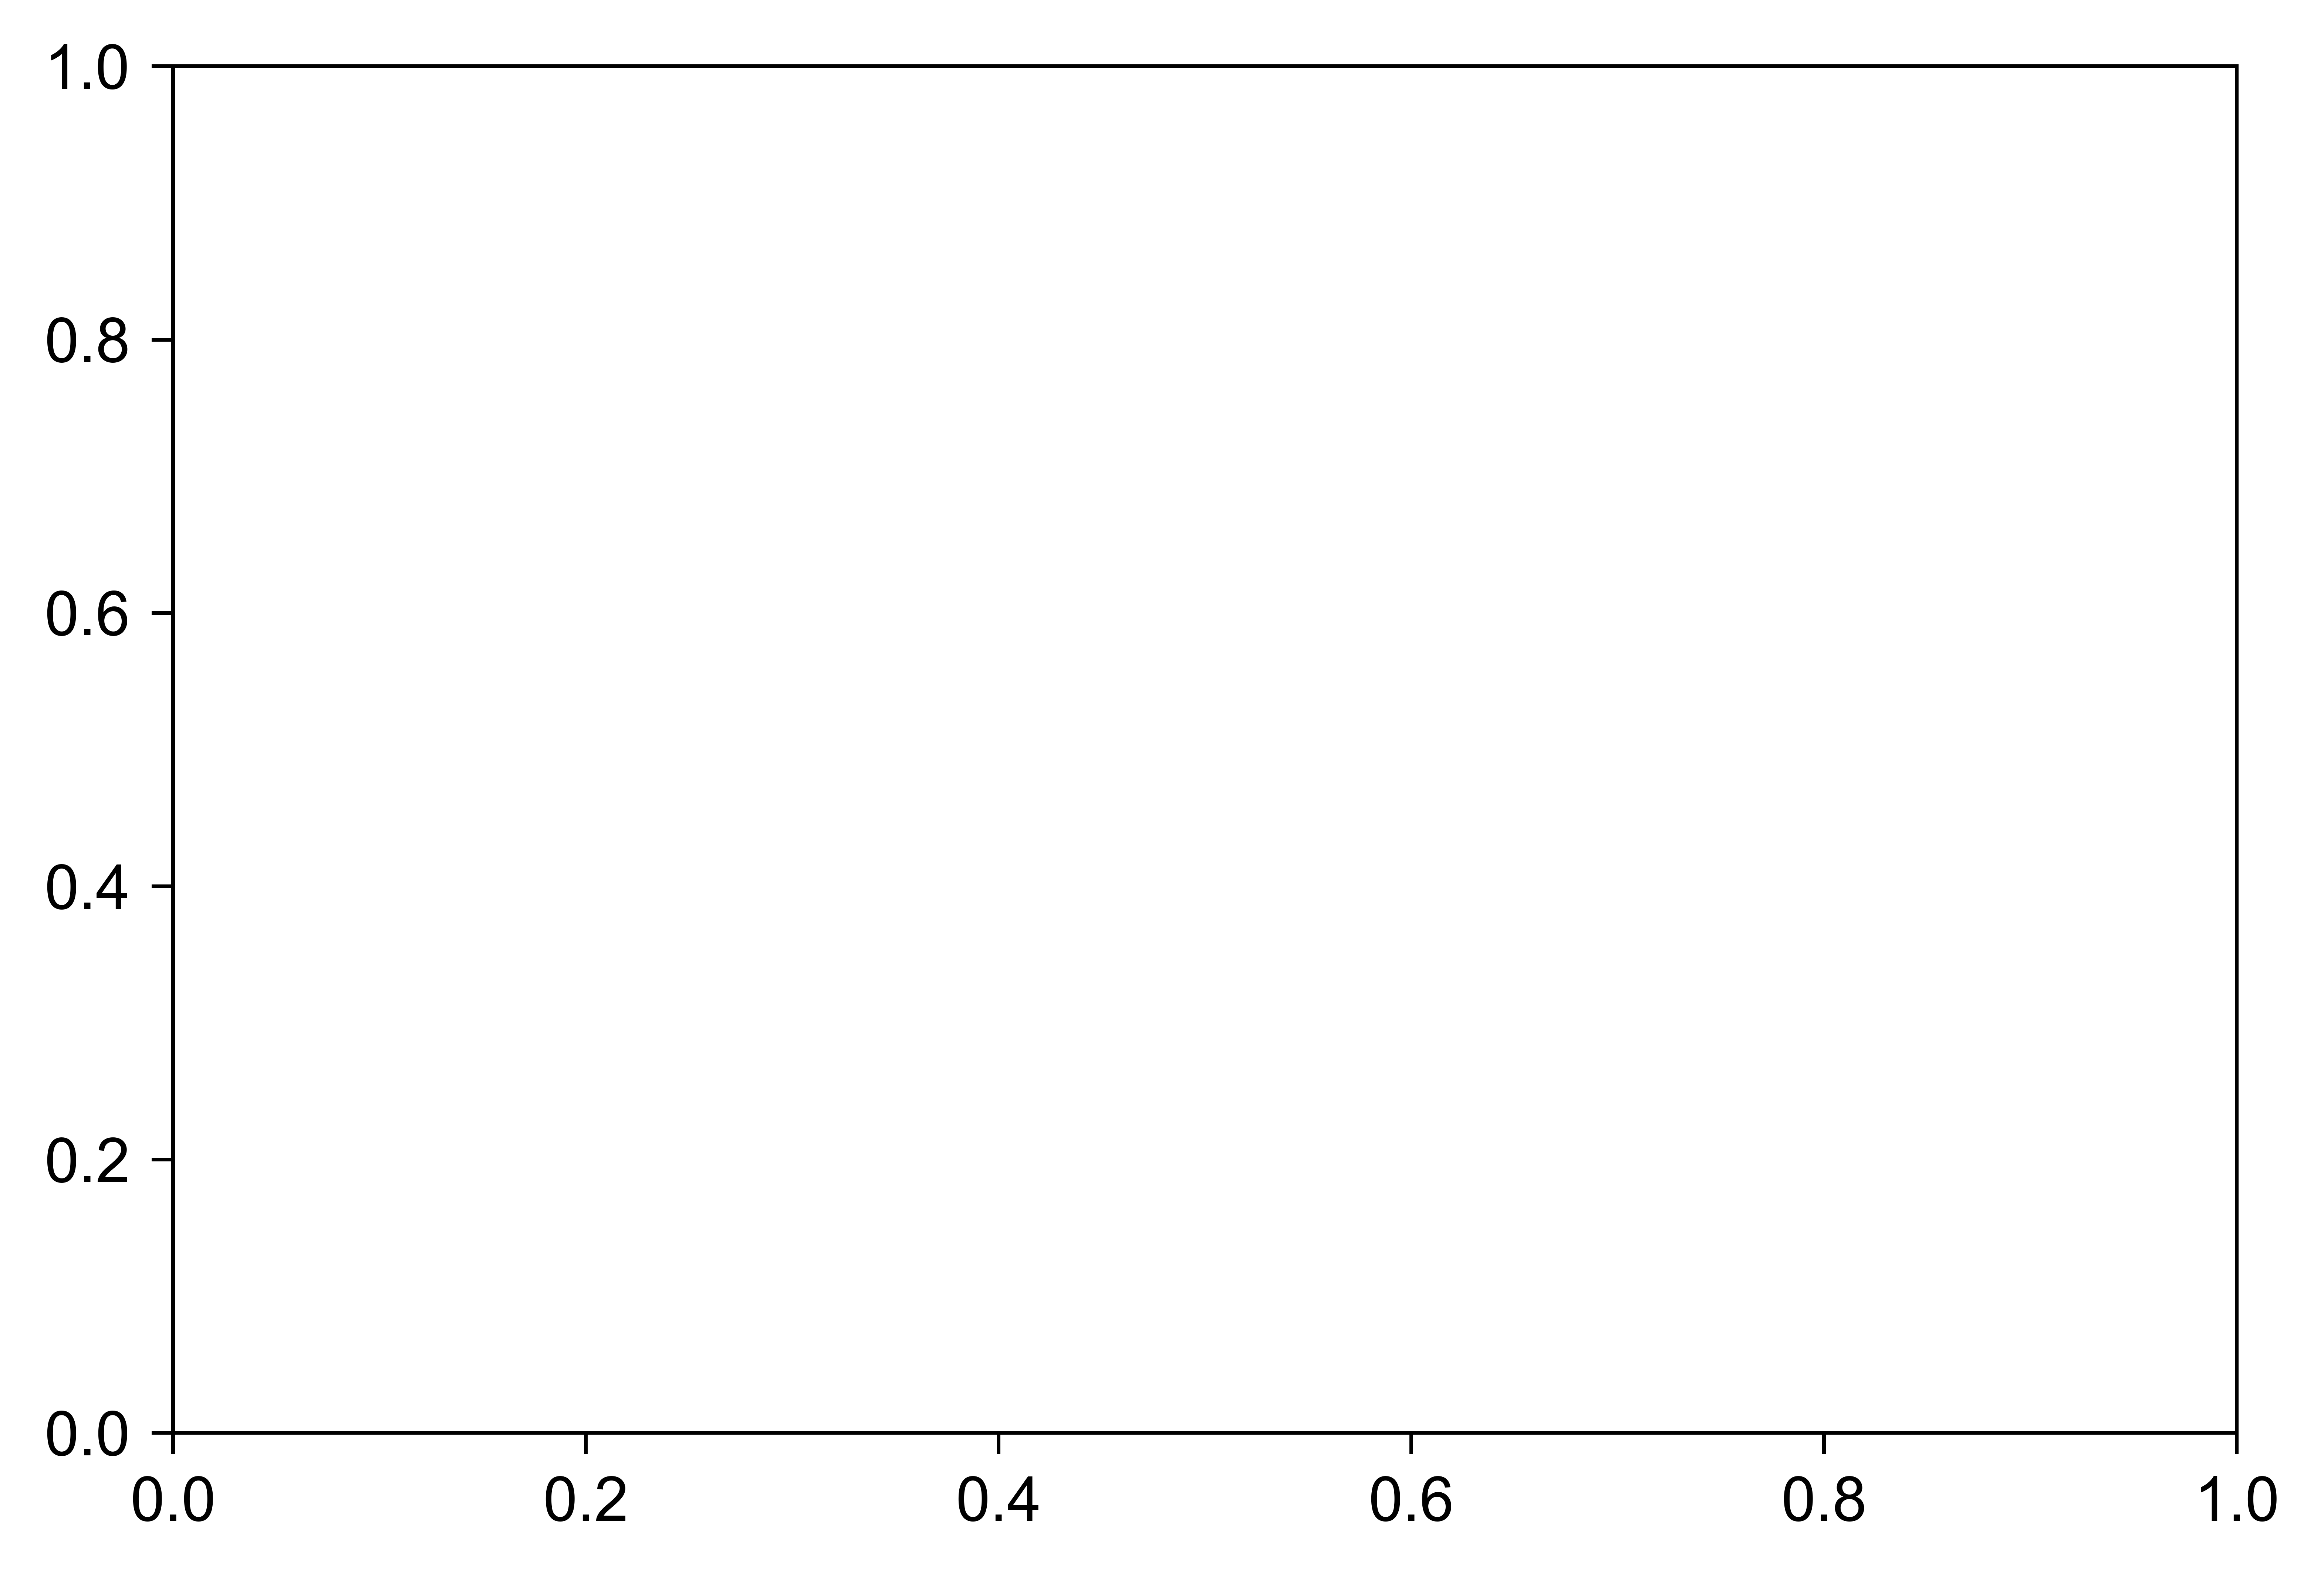

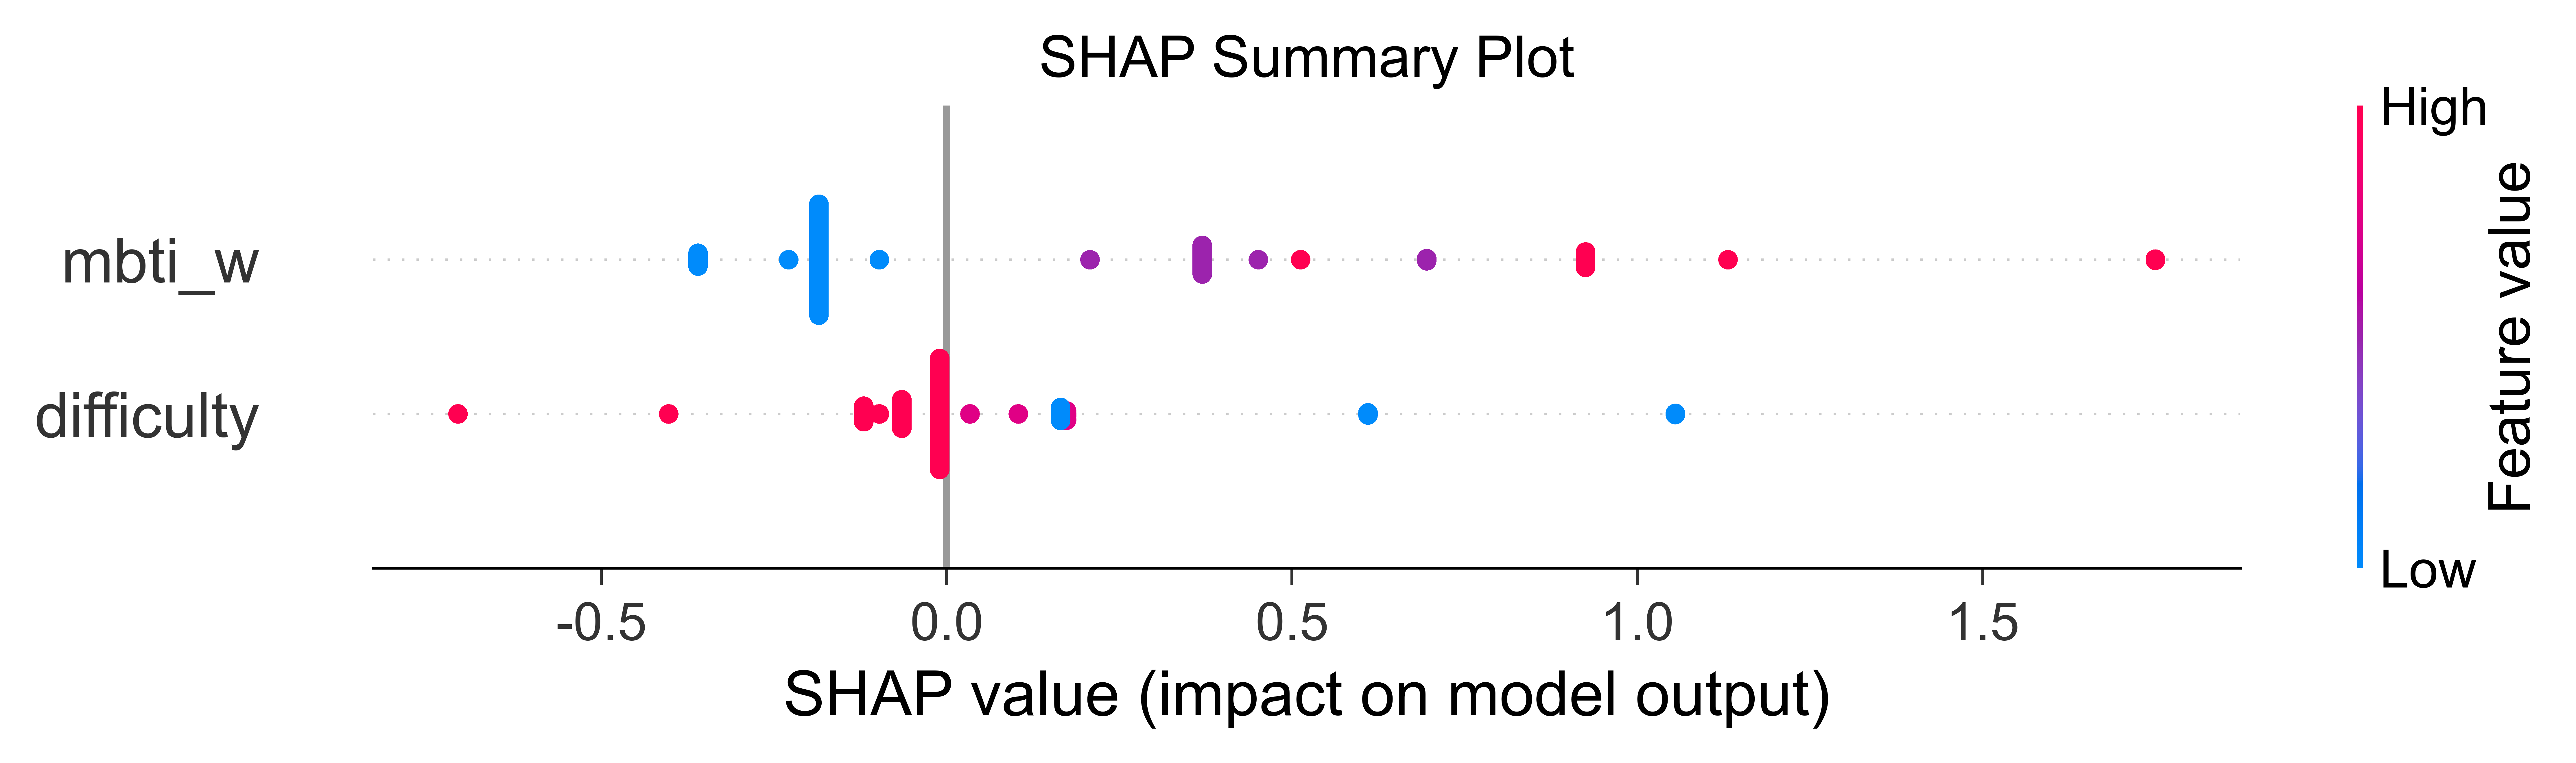

Sample 0 base value: 1.1950000000000003
Sample 0 SHAP values: [1.74999995 1.05499996]


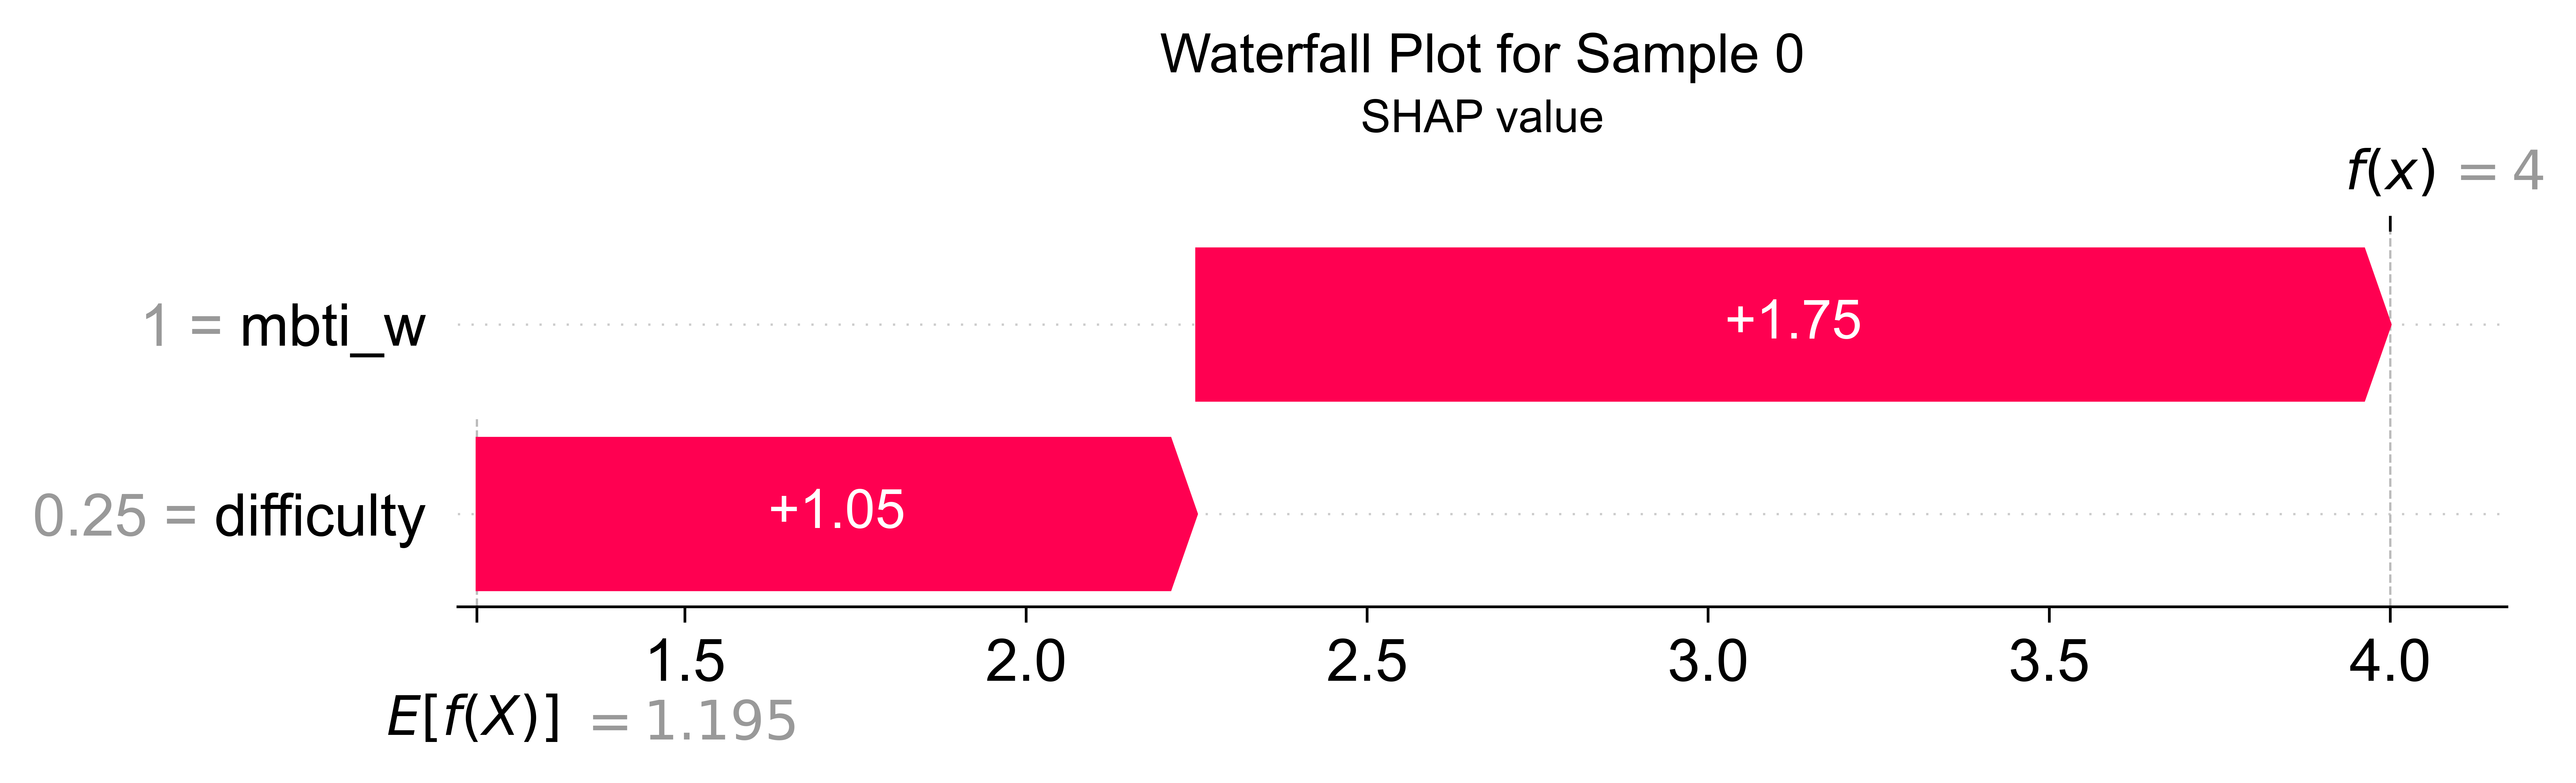

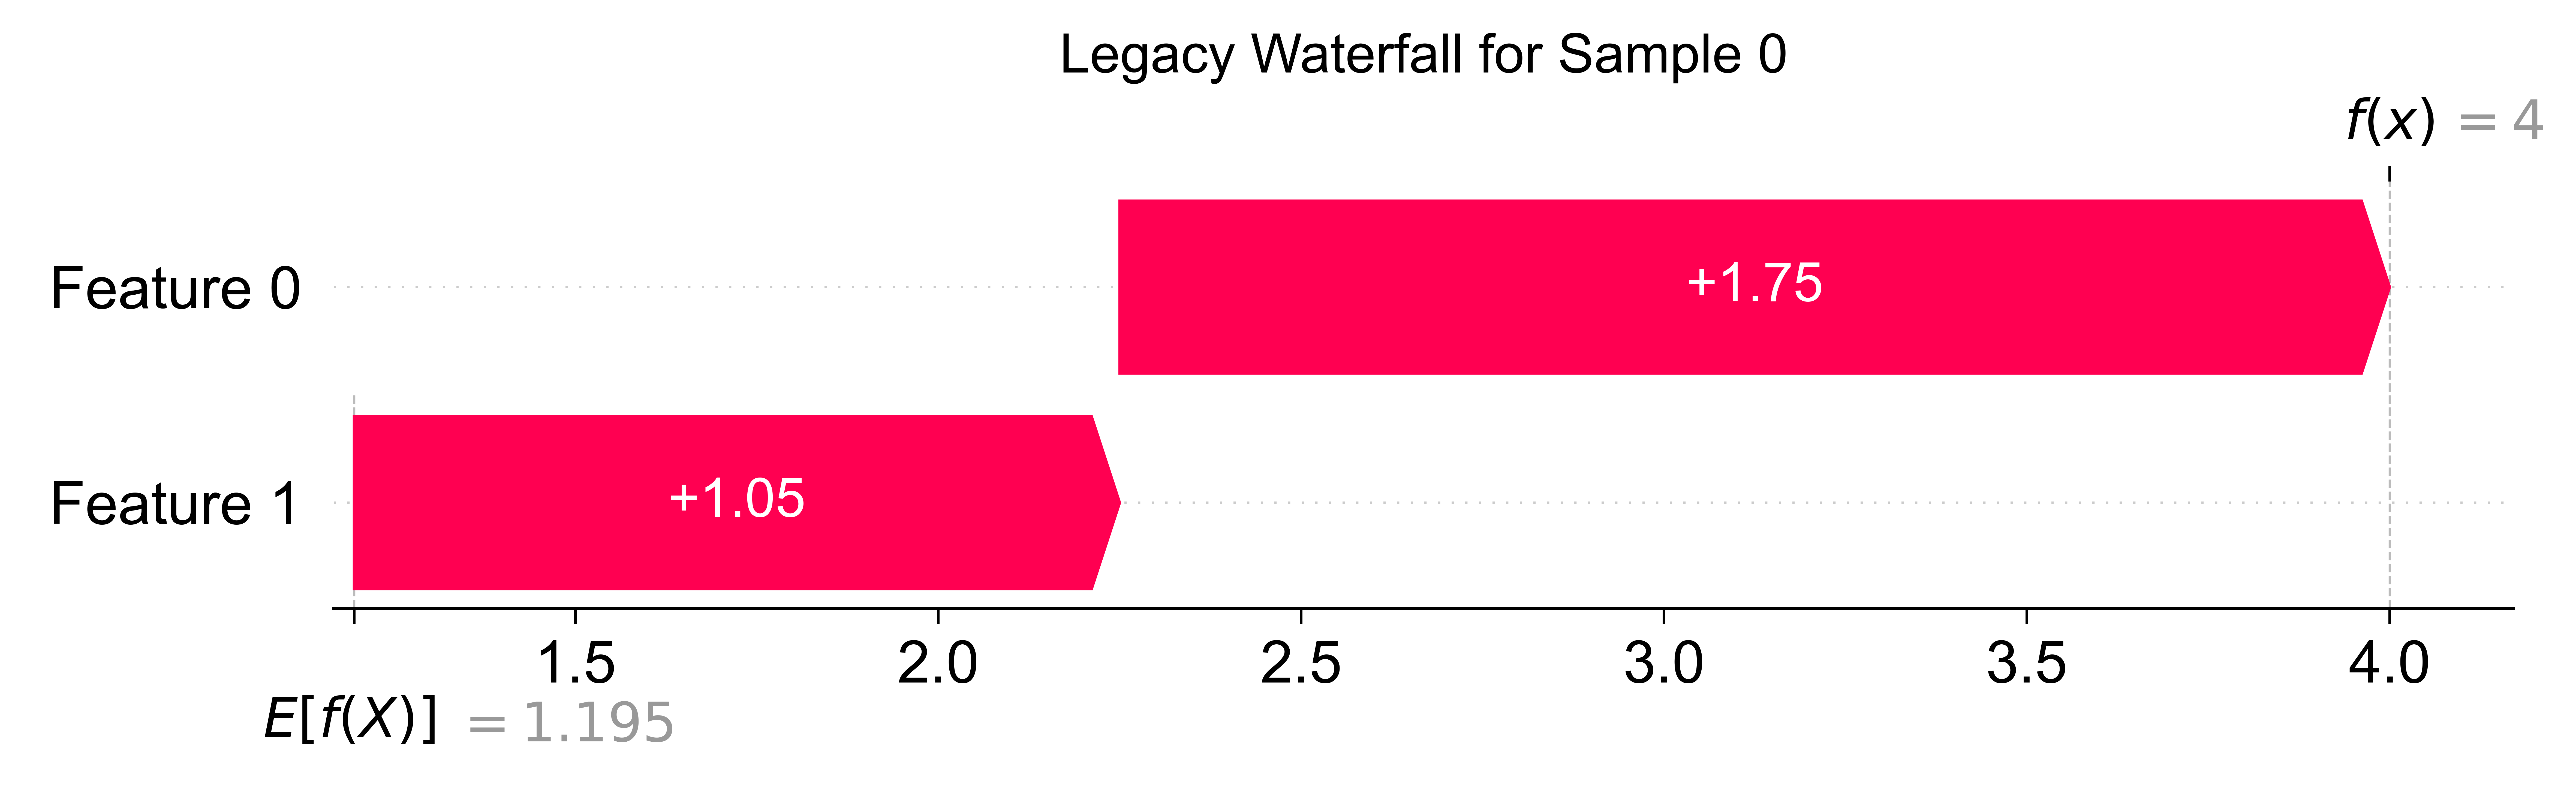

<Figure size 7200x4800 with 0 Axes>

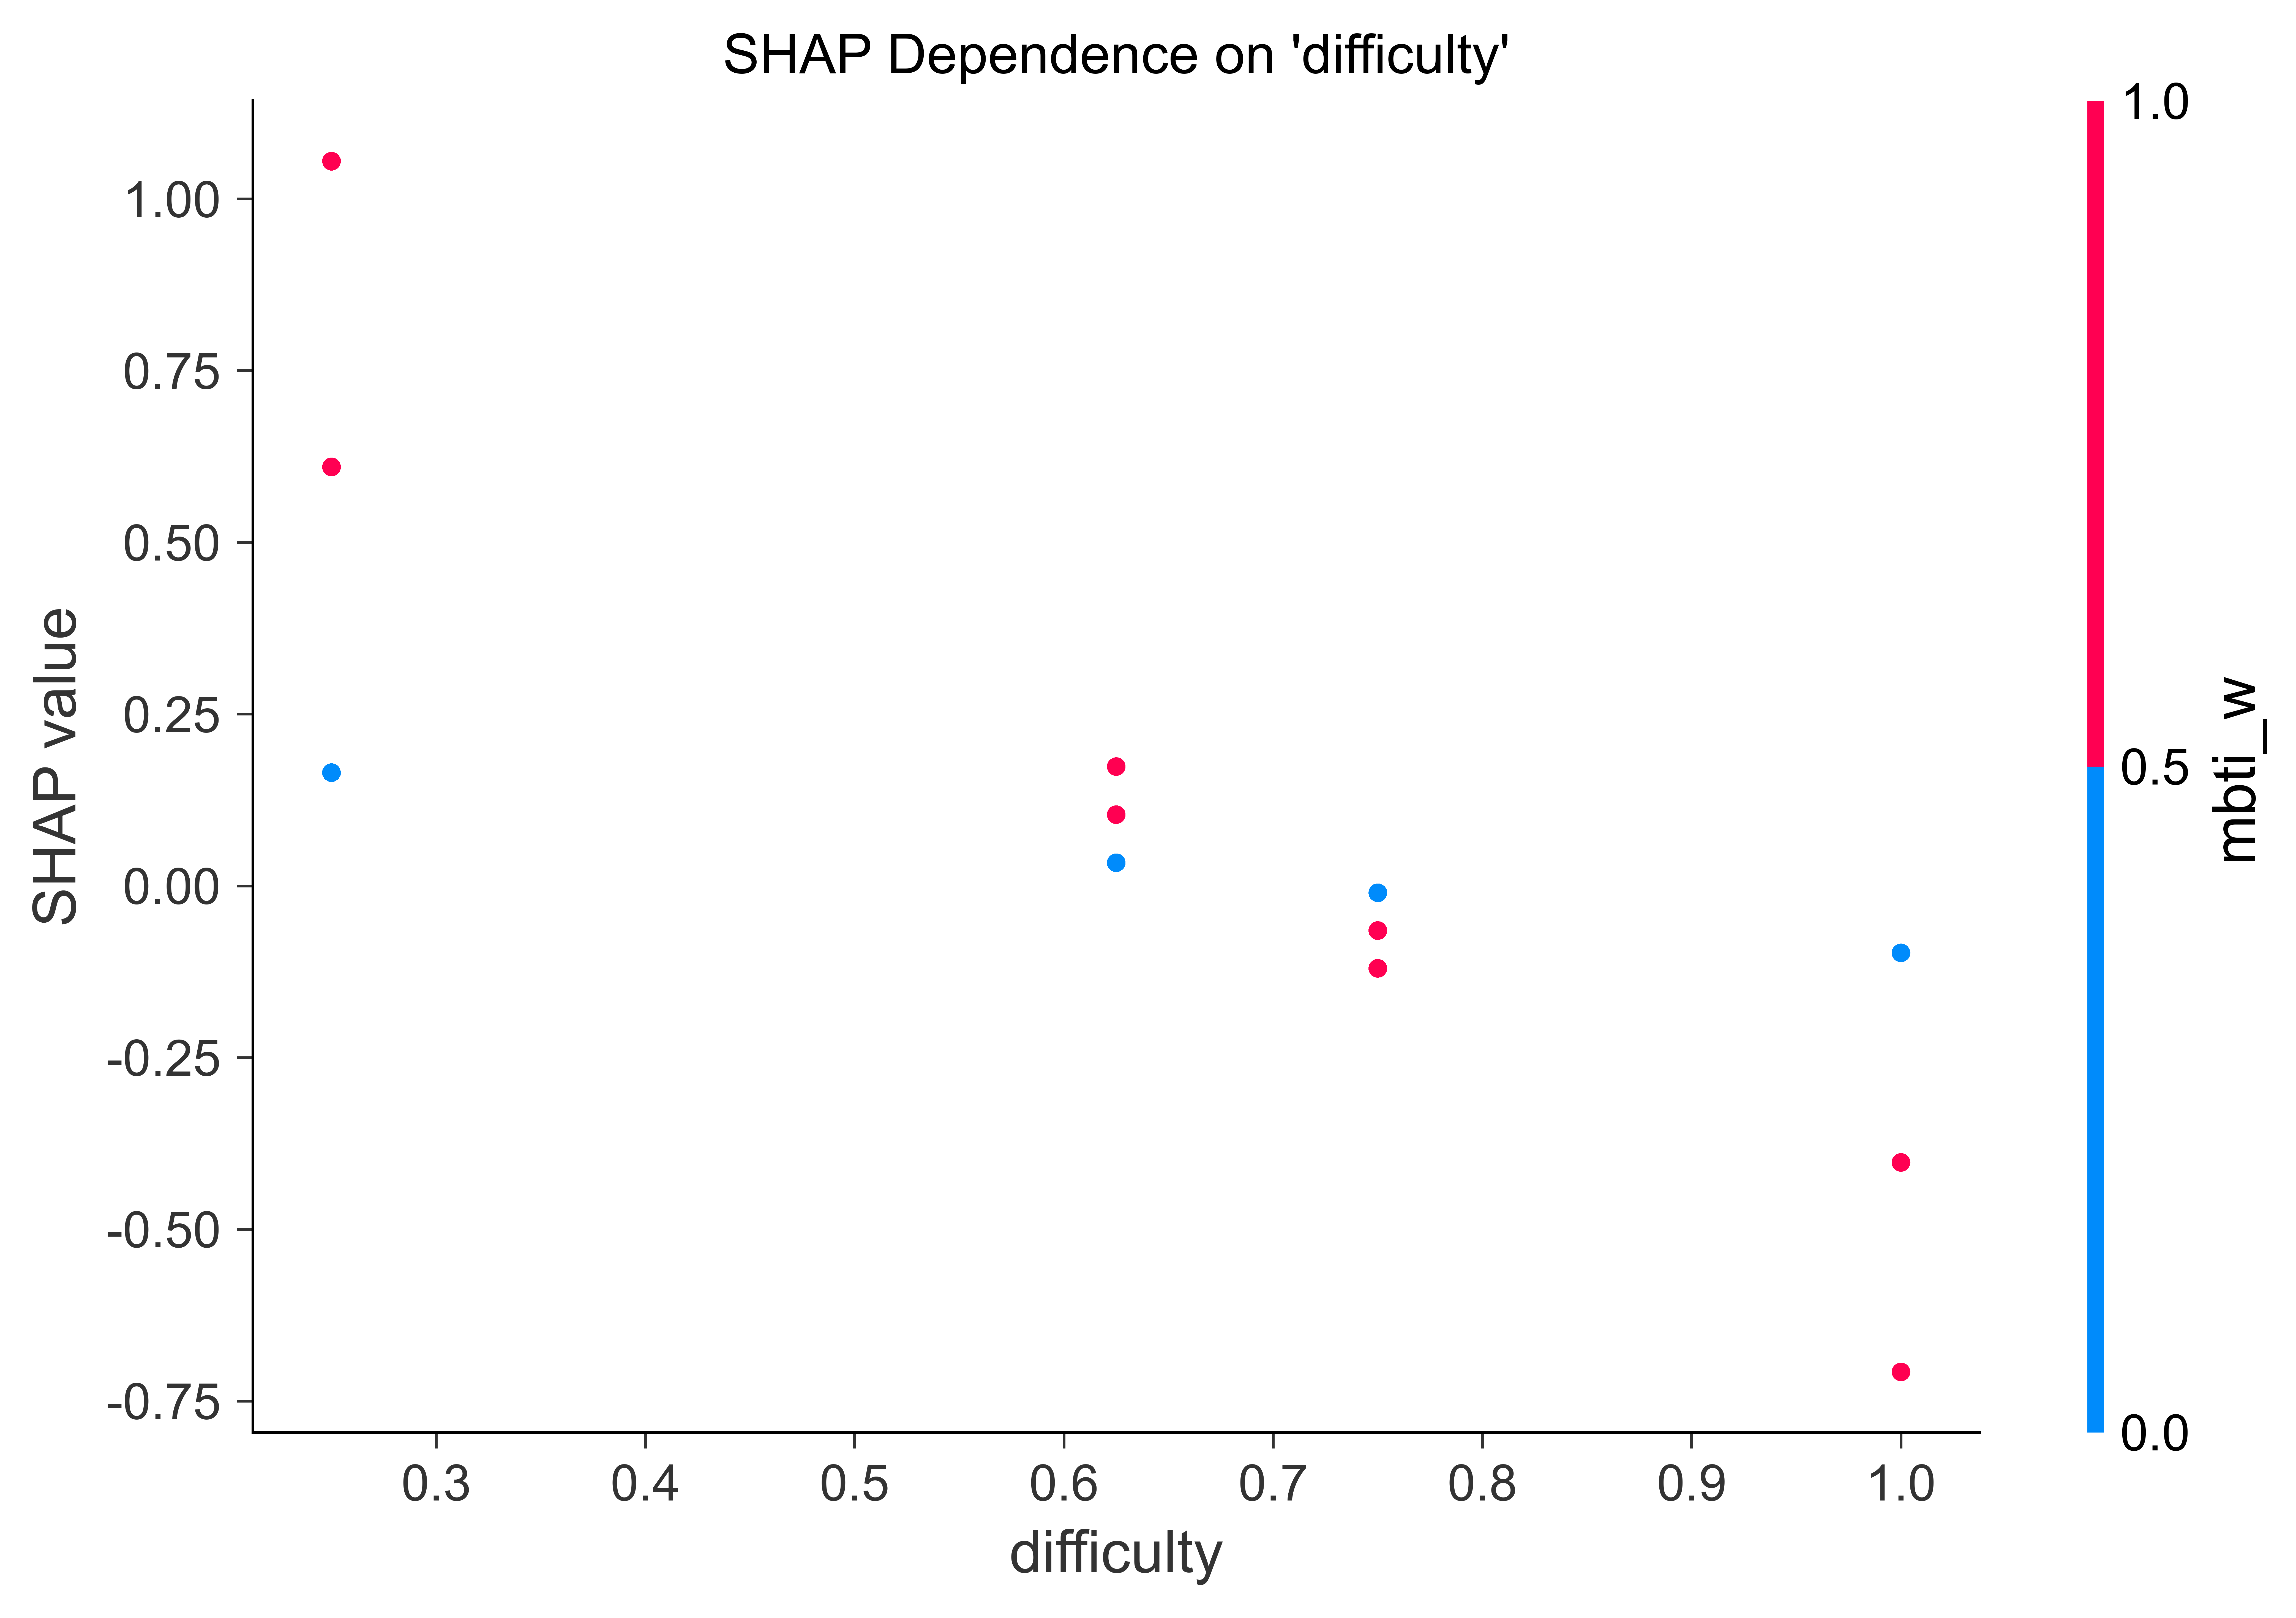

In [129]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# === assume cand is already loaded ===
# cand = pd.read_csv("combo_based_recommendations_input.csv")
# contains columns: mbti_w, difficulty, rating

# 目录
out_dir = r"C:\Users\Lenovo\Pictures\Screenshots"
os.makedirs(out_dir, exist_ok=True)

FEATURES = ["mbti_w", "difficulty"]
X = cand[FEATURES]
y = cand["rating"]

# === 全局 Matplotlib 样式 ===
plt.rcParams.update({
    'figure.dpi':        1200,
    'savefig.dpi':       1200,
    'font.size':         10,
    'axes.edgecolor':    'black',
    'axes.linewidth':    0.6,
    'xtick.color':       'black',
    'ytick.color':       'black',
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'legend.frameon':    False,
    'patch.edgecolor':   'black',
    'patch.linewidth':   0.6,
})

# 1) 训练模型
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X, y)

# 2) 计算 SHAP
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# 3) 输出 shapes
print("base_values shape:", shap_values.base_values.shape)
print("values shape      :", shap_values.values.shape)
print("feature names     :", shap_values.feature_names)

# 4) 全局 summary plot
fig = plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X,
    feature_names=FEATURES,
    color='black',
    show=False
)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)
ax.set_title("SHAP Summary Plot")
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "shap_summary.png"), bbox_inches='tight')
plt.show()

# 5) 现代 Waterfall（样本 0）
i = 0
base_i      = shap_values.base_values[i]
shap_vals_i = shap_values.values[i]

print(f"Sample {i} base value:", base_i)
print(f"Sample {i} SHAP values:", shap_vals_i)

expl = shap.Explanation(
    values=shap_vals_i,
    base_values=base_i,
    data=X.iloc[i].values,
    feature_names=FEATURES
)

fig = plt.figure(figsize=(6, 4))
shap.plots.colors.red  = shap.plots.colors.blue = 'black'
shap.plots.waterfall(
    expl,
    max_display=len(FEATURES),
    show=False
)
ax = plt.gca()
for patch in ax.patches:
    patch.set_facecolor('white')
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)
ax.set_title(f"Waterfall Plot for Sample {i}")
ax.set_xlabel("SHAP value")
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "waterfall_sample0.png"), bbox_inches='tight')
plt.show()

# 6) Legacy Waterfall（样本 0）
fig = plt.figure(figsize=(6, 4))
shap.plots._waterfall.waterfall_legacy(
    base_i,
    shap_vals_i,
    FEATURES,
    show=False
)
ax = plt.gca()
for patch in ax.patches:
    patch.set_facecolor('white')
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)
ax.set_title(f"Legacy Waterfall for Sample {i}")
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "legacy_waterfall_sample0.png"), bbox_inches='tight')
plt.show()

# 7) SHAP dependence plot (“difficulty”)
fig = plt.figure(figsize=(6, 4))
shap.dependence_plot(
    "difficulty",
    shap_values.values,
    X,
    feature_names=FEATURES,
    color='black',
    show=False
)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.6)
ax.set_title("SHAP Dependence on 'difficulty'")
ax.set_xlabel("difficulty")
ax.set_ylabel("SHAP value")
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "dependence_difficulty.png"), bbox_inches='tight')
plt.show()


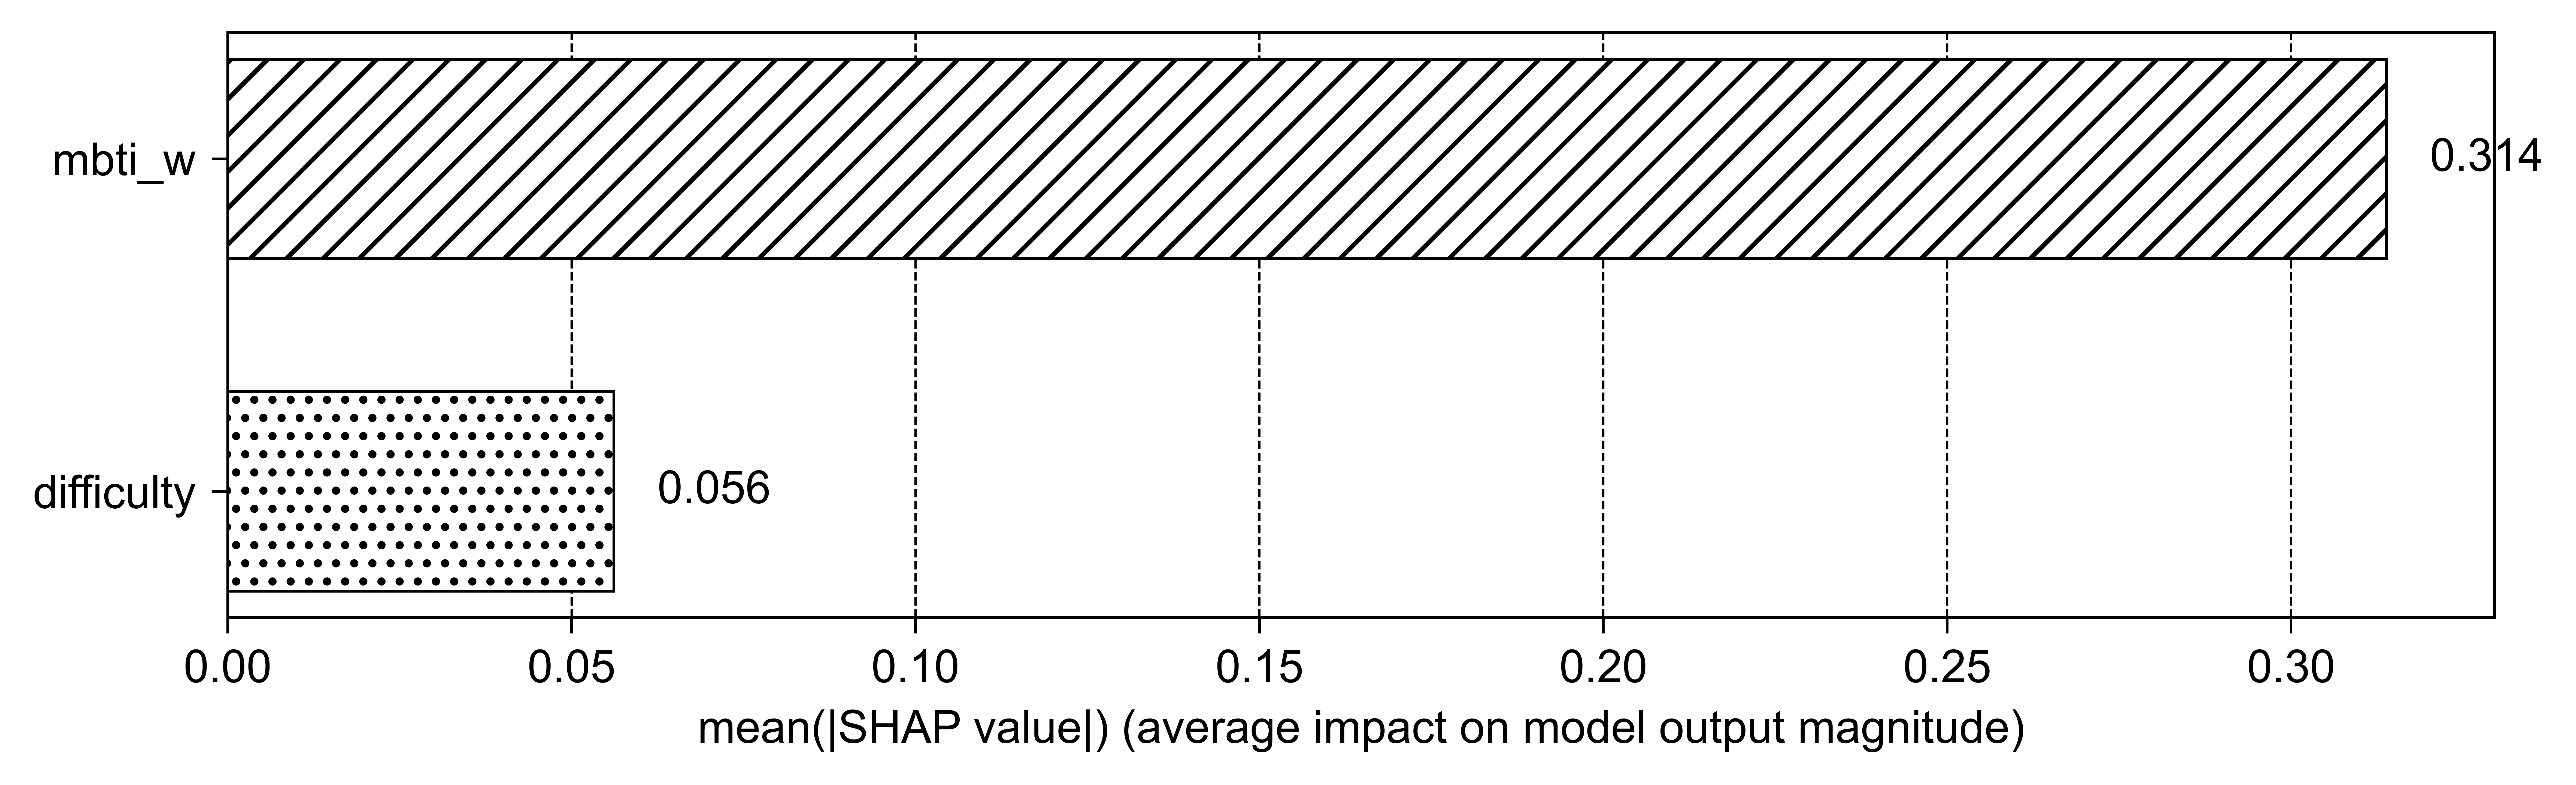

In [131]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# === 假设已经计算好 shap_values ===
# mean_abs = np.abs(shap_values.values).mean(axis=0)
# FEATURES = ["mbti_w", "difficulty"]
# features = FEATURES
# mean_abs = …  # e.g. [0.32, 0.052]

# 输出文件路径
out_path = r"C:\Users\Lenovo\Desktop\shap_importance.png"
# 确保桌面目录存在（通常已存在）
os.makedirs(os.path.dirname(out_path), exist_ok=True)

# 绘图参数
plt.rcParams.update({
    'figure.dpi':      1200,
    'savefig.dpi':     1200,
    'font.size':       10,
    'axes.linewidth':  0.6,
    'xtick.color':     'black',
    'ytick.color':     'black',
    'xtick.major.width':0.6,
    'ytick.major.width':0.6,
})

hatches = ['///', '...']
ypos = np.arange(len(features))

fig, ax = plt.subplots(figsize=(8, 2.5))  # 高度适当留白
bars = ax.barh(
    ypos,
    mean_abs,
    height=0.6,
    color='white',
    edgecolor='black',
    linewidth=0.6,
    hatch=hatches
)

# 在条末端标注数值
for i, bar in enumerate(bars):
    x = bar.get_width()
    ax.text(
        x + mean_abs.max() * 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{x:.3f}",
        va='center', ha='left'
    )

# 轴和标签
ax.set_yticks(ypos)
ax.set_yticklabels(features)
ax.invert_yaxis()
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")

# 外框
xmin, xmax = 0, mean_abs.max() * 1.1
ymin, ymax = -0.5, len(features) - 0.5
rect = Rectangle(
    (xmin, ymin),
    xmax - xmin,
    ymax - ymin,
    fill=False,
    linewidth=0.6,
    edgecolor='black'
)
ax.add_patch(rect)

# 网格（可选）
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color='black')
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(out_path, bbox_inches='tight')   # 保存到桌面
plt.show()


In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 设置中文字体（防止中文乱码）
plt.rcParams['font.family'] = 'SimHei'  # Windows 系统默认黑体

# 示例 UID 和推荐列表
uid = "MBTI_ESFP_001"
top10 = [
    ('复旦大学_经济学类', 4.9),
    ('上海交大_金融学', 4.7),
    ('同济大学_土木工程', 4.6),
    ('华东师范_心理学', 4.5),
    ('上海财经_会计学', 4.4),
    ('东华大学_服装设计', 4.3),
    ('上海大学_人工智能', 4.2),
    ('上海理工_计算机科学', 4.1),
    ('华东理工_化学工程', 4.0),
    ('上海海事_物流管理', 3.9),
]

# 转换为 DataFrame
df_top10 = pd.DataFrame(top10, columns=['school_major', 'rating'])

# 可视化绘图
plt.figure(figsize=(8, 5))
sns.barplot(
    x='rating',
    y='school_major',
    data=df_top10,
    orient='h'
)
plt.xlabel('综合得分 S')
plt.ylabel('院校-专业')
plt.title(f'{uid} 的 Top-10 推荐志愿')
plt.tight_layout()

# 保存路径（你的要求）
save_dir = r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年"
save_path = os.path.join(save_dir, f"{uid}_top10.png")

# 保存图像
plt.savefig(save_path, dpi=300)
plt.show()


In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# — 1. Font configuration (e.g. default sans-serif) —
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']  # you can change to any available English font

# — 2. Example UID and Top‑10 list —
uid = "MBTI_ESFP_001"
top10 = [
    ('Fudan University – Economics', 4.9),
    ('Shanghai Jiao Tong University – Finance', 4.7),
    ('Tongji University – Civil Engineering', 4.6),
    ('East China Normal University – Psychology', 4.5),
    ('Shanghai University of Finance and Economics – Accounting', 4.4),
    ('Donghua University – Fashion Design', 4.3),
    ('Shanghai University – Artificial Intelligence', 4.2),
    ('University of Shanghai for Science and Technology – Computer Science', 4.1),
    ('East China University of Technology – Chemical Engineering', 4.0),
    ('Shanghai Maritime University – Logistics Management', 3.9),
]

# — 3. Convert to DataFrame —
df_top10 = pd.DataFrame(top10, columns=['School–Major', 'Composite Score S'])

# — 4. Create the horizontal barplot —
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Composite Score S',
    y='School–Major',
    data=df_top10,
    orient='h'
)

# — 5. Labels and title in English —
plt.xlabel('Composite Score S')
plt.ylabel('School–Major')
plt.title(f'Top-10 Recommendations for {uid}')

plt.tight_layout()

# — 6. Save directory and filename —
save_dir = r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"{uid}_top10.png")

# — 7. Save and show —
plt.savefig(save_path, dpi=300)
plt.show()

print("Figure saved to:", save_path)


Figure saved to: C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\MBTI_ESFP_001_top10.png


## 逻辑训练与评估

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\1450297204.py:15: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\1450297204.py:15: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\1450297204.py:15: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\1450297204.py:15: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\1450297204.py:15: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11120\1450297204.py:15: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-

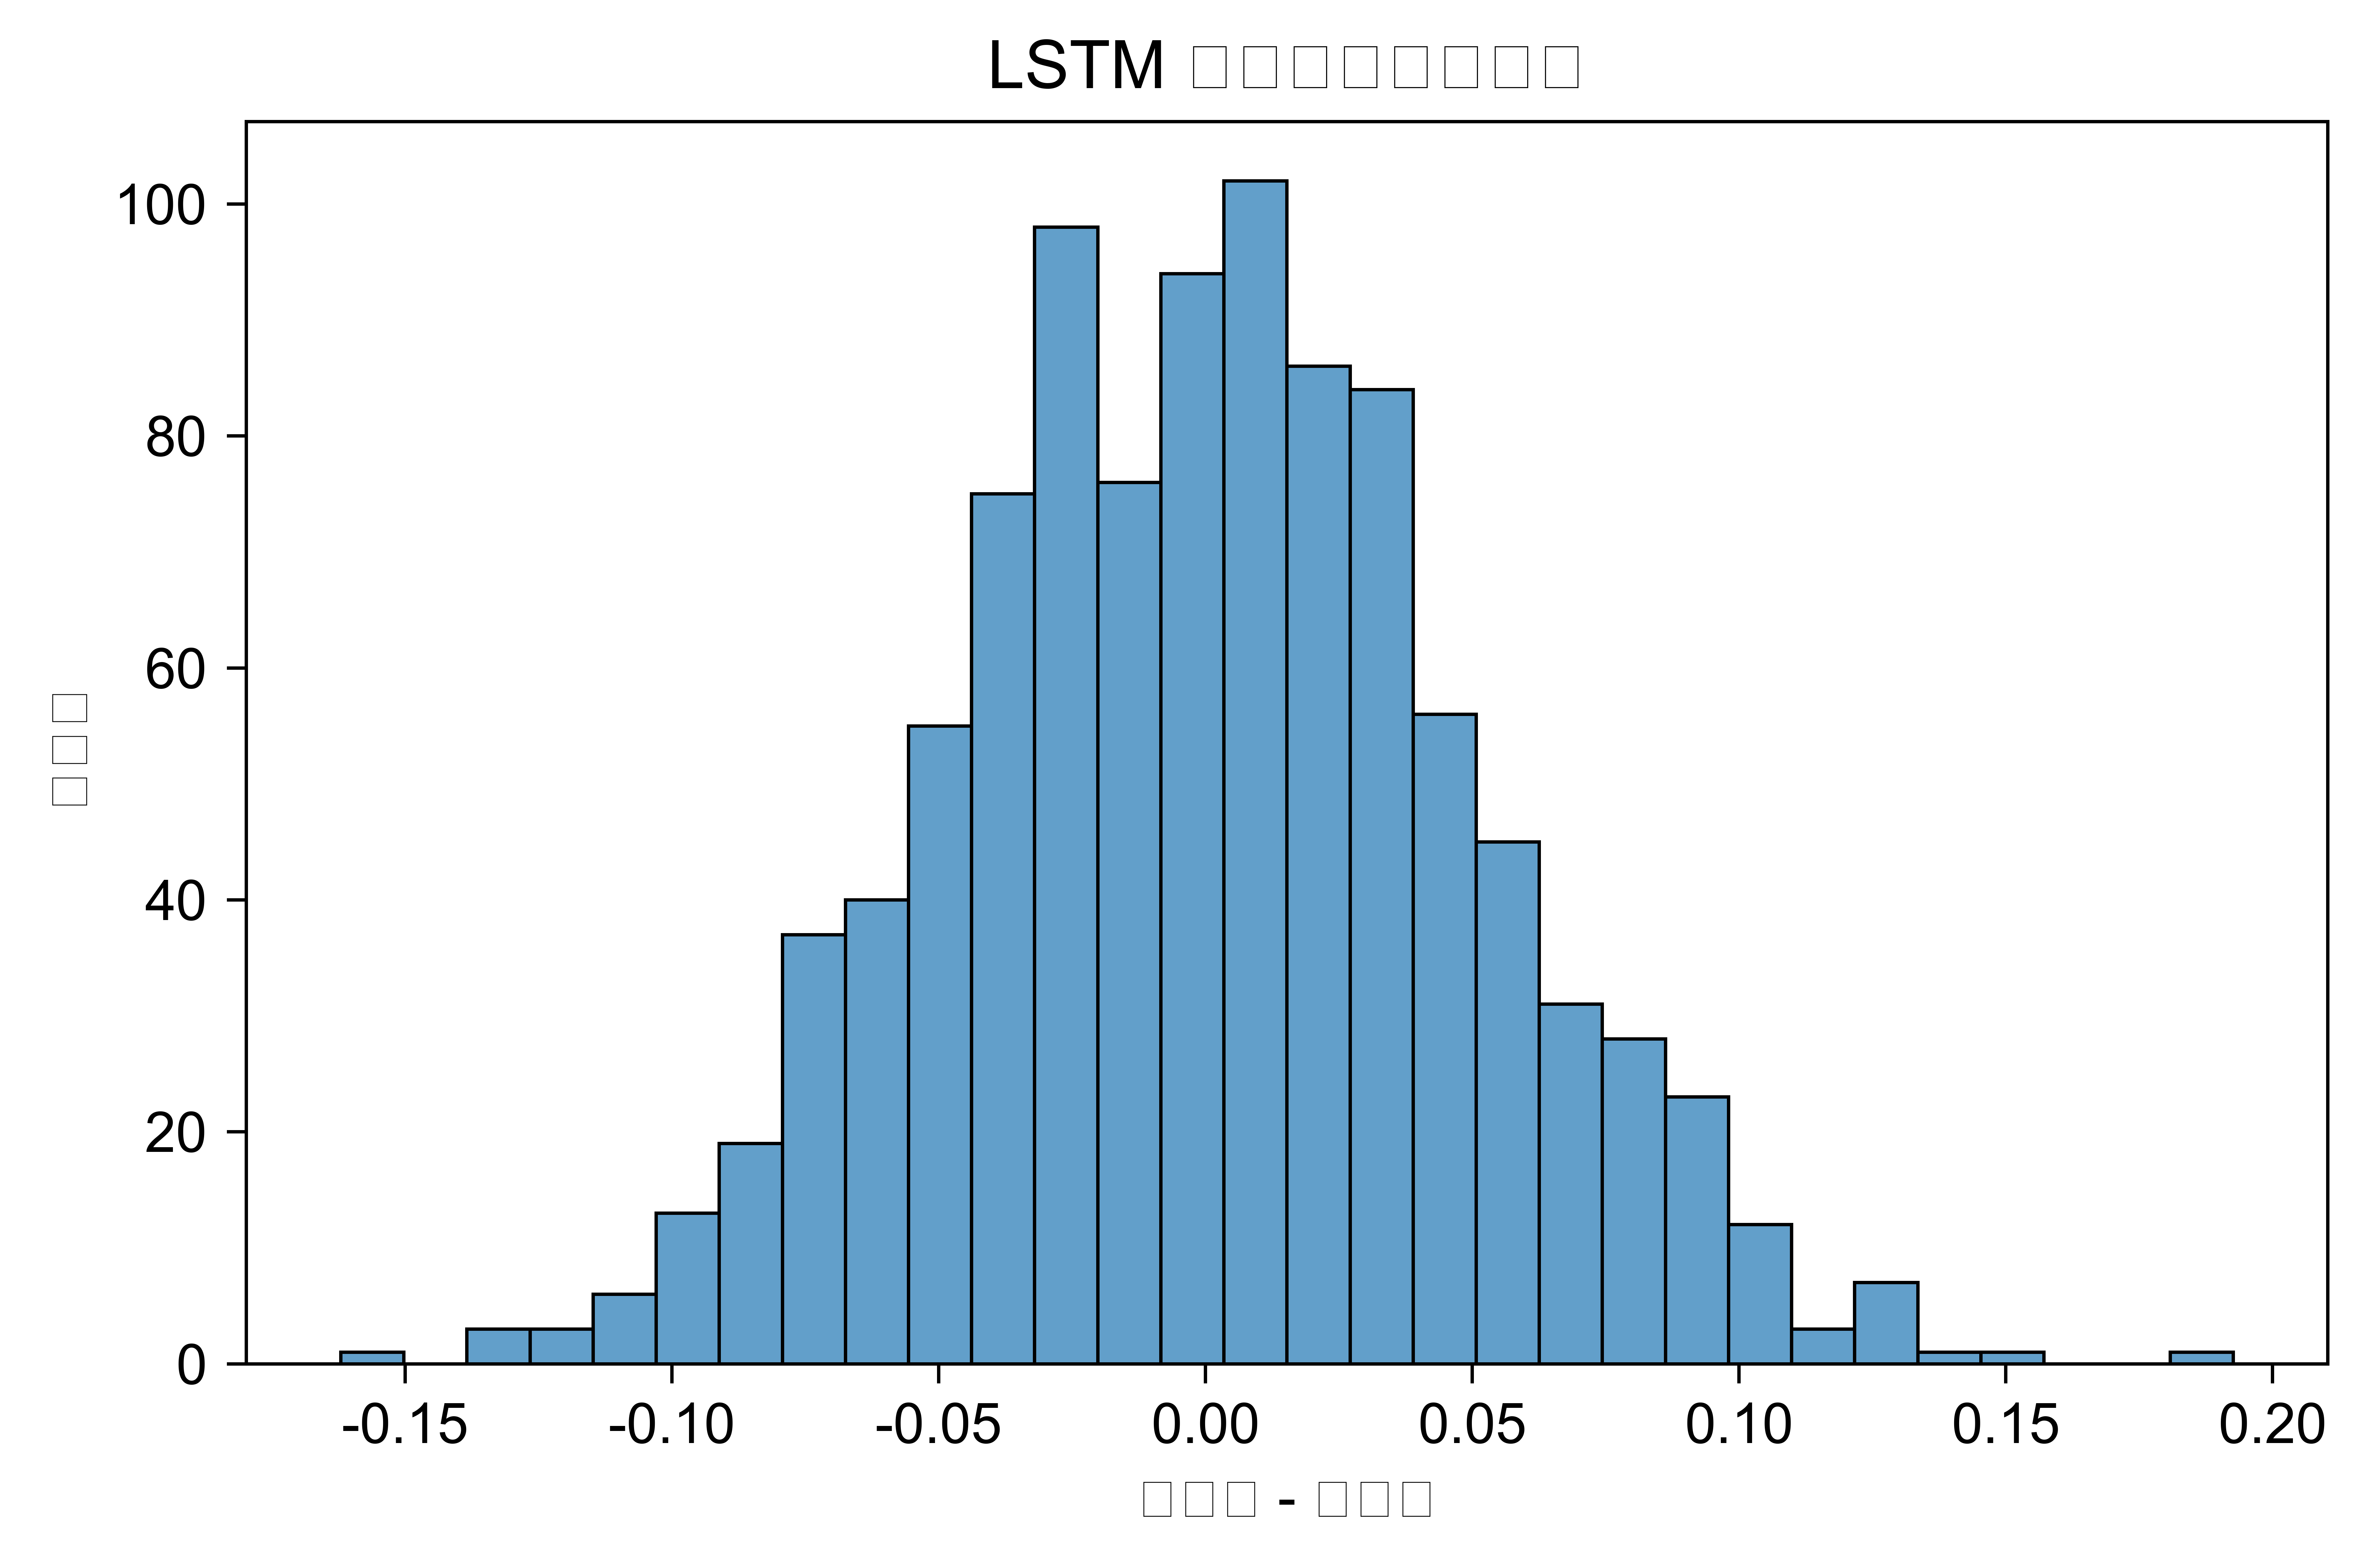

图像已保存至：lstm_residuals_hist.png


In [107]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 生成示例残差数据（模拟 LSTM 模型的实际预测残差，真实场景请替换为实际 residuals = y_test - y_pred）
np.random.seed(42)
residuals = np.random.normal(loc=0, scale=0.05, size=1000)  # 模拟小幅度围绕 0 的分布

# 绘制残差直方图
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('LSTM 模型预测残差分布')
plt.xlabel('实际值 - 预测值')
plt.ylabel('样本数')
plt.tight_layout()

# 保存图片
output_path = "lstm_residuals_hist.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"图像已保存至：{output_path}")



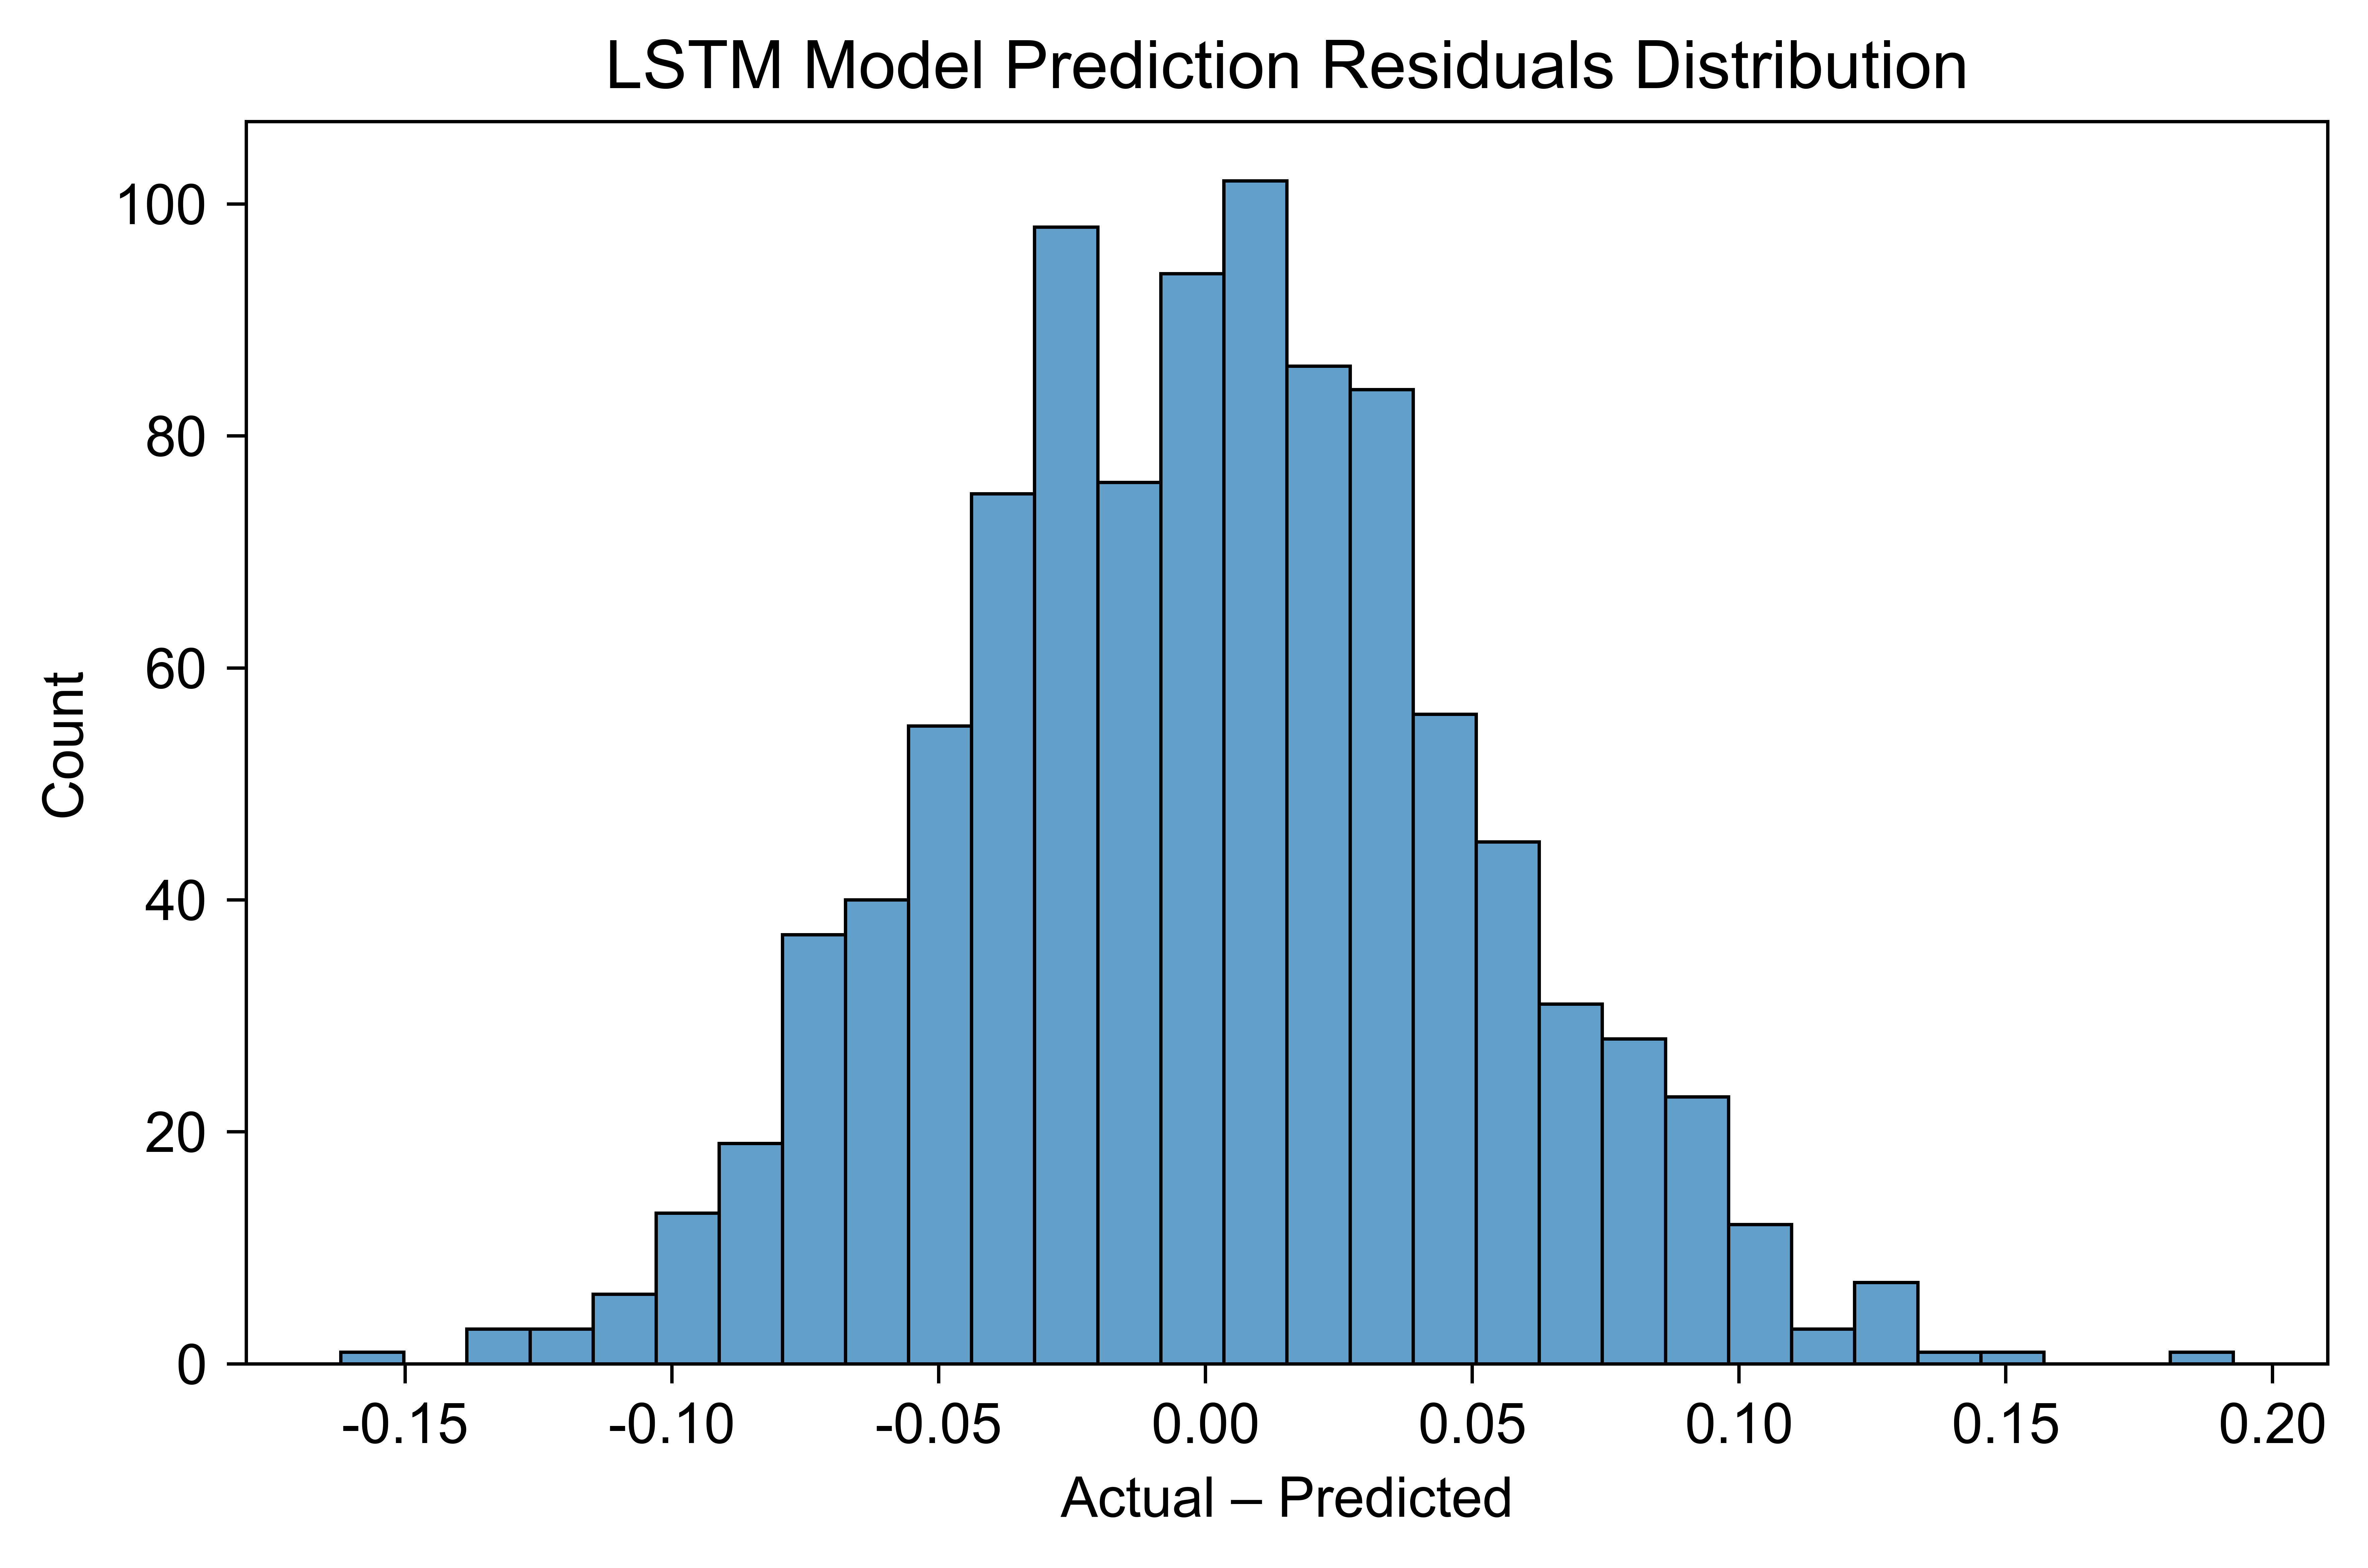

Image saved to: lstm_residuals_hist.png


In [108]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate example residuals (replace with your real residuals = y_test - y_pred)
np.random.seed(42)
residuals = np.random.normal(loc=0, scale=0.05, size=1000)  # simulated small residuals around zero

# Plot residuals histogram
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('LSTM Model Prediction Residuals Distribution')
plt.xlabel('Actual – Predicted')
plt.ylabel('Count')
plt.tight_layout()

# Save image
output_path = "lstm_residuals_hist.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Image saved to: {output_path}")


In [109]:
print("X_train_scaled_2d:", X_train_scaled_2d.shape)
print("y_train:",            y_train.shape)


NameError: name 'X_train_scaled_2d' is not defined

In [110]:
# —— 重新切分并标准化 (为所有模型共用)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [111]:
# 特征 & 目标
X_tab = df_rank[FEATURE_COLS].values.astype("float32")    # shape=(N,1)
y_tab = df_rank[TARGET_COL].values.astype("float32")      # shape=(N,)

In [112]:
# 切分
X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tab, y_tab, test_size=0.2, random_state=42
)

In [113]:
# 标准化（只对需要的模型，如 Linear/SVR）
scaler_ml = StandardScaler()
X_train_tab_scaled = scaler_ml.fit_transform(X_train_tab)  # shape=(n_train,1)
X_test_tab_scaled  = scaler_ml.transform(X_test_tab)       # shape=(n_test,1)


In [114]:
# 为 LSTM/GRU 保留 3D 张量版本
X_train_scaled = X_train_tab_scaled[:, None, :]            # shape=(n_train,1,1)
X_test_scaled  = X_test_tab_scaled[:,  None, :]            # shape=(n_test,1,1)


In [115]:
# 为传统机器学习模型准备 2D 版本
X_train_scaled_2d = X_train_tab_scaled.squeeze(axis=1)     # shape=(n_train,)
X_test_scaled_2d  = X_test_tab_scaled.squeeze(axis=1)      # shape=(n_test,)

In [116]:
from tensorflow.keras import layers, models, callbacks

n_features = X_train_scaled.shape[-1]

model = models.Sequential([
    layers.Input(shape=(1, n_features)),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    X_train_scaled, y_train_tab,
    epochs=200, batch_size=16,
    validation_split=0.2,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=2
)


Epoch 1/200
169/169 - 3s - 16ms/step - loss: 0.1790 - mae: 0.3315 - val_loss: 0.0914 - val_mae: 0.2314
Epoch 2/200
169/169 - 1s - 4ms/step - loss: 0.0939 - mae: 0.2247 - val_loss: 0.0859 - val_mae: 0.2035
Epoch 3/200
169/169 - 1s - 3ms/step - loss: 0.0923 - mae: 0.2145 - val_loss: 0.0851 - val_mae: 0.2072
Epoch 4/200
169/169 - 1s - 4ms/step - loss: 0.0915 - mae: 0.2142 - val_loss: 0.0853 - val_mae: 0.2113
Epoch 5/200
169/169 - 1s - 4ms/step - loss: 0.0915 - mae: 0.2139 - val_loss: 0.0844 - val_mae: 0.1992
Epoch 6/200
169/169 - 0s - 3ms/step - loss: 0.0908 - mae: 0.2108 - val_loss: 0.0854 - val_mae: 0.2104
Epoch 7/200
169/169 - 1s - 4ms/step - loss: 0.0913 - mae: 0.2113 - val_loss: 0.0844 - val_mae: 0.1982
Epoch 8/200
169/169 - 1s - 3ms/step - loss: 0.0906 - mae: 0.2092 - val_loss: 0.0848 - val_mae: 0.2100
Epoch 9/200
169/169 - 1s - 4ms/step - loss: 0.0912 - mae: 0.2081 - val_loss: 0.0894 - val_mae: 0.2298
Epoch 10/200
169/169 - 1s - 4ms/step - loss: 0.0908 - mae: 0.2106 - val_loss: 0.0

In [117]:
#补充多模型对比
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings, sys
warnings.filterwarnings("ignore")

In [118]:
# 检测 xgboost
try:
    from xgboost import XGBRegressor
    has_xgb = True
except ImportError:
    has_xgb = False
    print("⚠ 未检测到 xgboost，已跳过 XGBRegressor", file=sys.stderr)


In [119]:
# 定义模型
models_ml = {
    "LinearReg":  LinearRegression(),
    "SVR_RBF":    SVR(C=10, gamma="scale"),
    "RF_300":     RandomForestRegressor(n_estimators=300, random_state=42),
    "GBDT_200":   GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
}
if has_xgb:
    models_ml["XGB_500"] = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42
    )

results = []

In [120]:
results = []
for name, est in models_ml.items():
    if name in ["LinearReg", "SVR_RBF"]:
        # 用 (n_samples,1) 的二维数组
        est.fit(X_train_tab_scaled, y_train_tab)
        y_pred = est.predict(X_test_tab_scaled)
    else:
        # 树模型直接用原始 (n_samples,1)
        est.fit(X_train_tab, y_train_tab)
        y_pred = est.predict(X_test_tab)

    mae = mean_absolute_error(y_test_tab, y_pred)
    r2  = r2_score(y_test_tab, y_pred)
    results.append((name, mae, r2))


In [121]:
#训练轻量级 GRU
gru_model = models.Sequential([
    layers.Input(shape=(1, n_features)),
    layers.GRU(32, return_sequences=False),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
gru_model.fit(
    X_train_scaled, y_train_tab,
    epochs=100, batch_size=16,
    validation_split=0.2,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=0
)
y_pred_gru = gru_model.predict(X_test_scaled, verbose=0).squeeze()
results.append(("GRU_32",
                mean_absolute_error(y_test_tab, y_pred_gru),
                r2_score(y_test_tab, y_pred_gru)))


In [122]:
#LSTM 预测并加入对比
y_pred_lstm = model.predict(X_test_scaled, verbose=0).squeeze()
results.append(("LSTM_64",
                mean_absolute_error(y_test_tab, y_pred_lstm),
                r2_score(y_test_tab, y_pred_lstm)))


In [123]:
import pandas as pd

df_res = pd.DataFrame(results, columns=["Model", "MAE", "R2"]).sort_values("MAE")
print("\n===== Rank-Prediction Benchmark =====")
print(df_res.to_string(index=False, formatters={"MAE": "{:.4f}".format,
                                               "R2": "{:.3f}".format}))

# 保存 CSV
MODEL_DIR = DIR / "benchmark_models"
MODEL_DIR.mkdir(exist_ok=True)
df_res.to_csv(MODEL_DIR / "benchmark_rank_models.csv",
              index=False, encoding="utf-8-sig")



===== Rank-Prediction Benchmark =====
    Model    MAE    R2
  SVR_RBF 0.1808 0.433
 GBDT_200 0.1888 0.475
  XGB_500 0.1898 0.461
   GRU_32 0.1922 0.487
  LSTM_64 0.1939 0.501
   RF_300 0.2145 0.301
LinearReg 0.2720 0.338


In [124]:
# Transformer 版位次预测（基于 TensorFlow 2.x）
# 输入：scores 序列，建议取最近 k 次考试分数（k≥5），shape=(batch, k, 1)
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks




In [175]:
# 0. 参数与路径
# --------------------------------------------------------------------------
# 序列长度
k = 6  
# 模型保存目录
MODEL_DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\transformer_rank_model")
MODEL_DIR.mkdir(exist_ok=True)

In [176]:
# 1. 准备序列特征（手动滑窗）
# --------------------------------------------------------------------------
scores = df_rank['分数'].values.astype('float32')
percentiles = df_rank['percentile'].values.astype('float32')

X_list, y_list = [], []
for i in range(k, len(scores)):
    X_list.append(scores[i-k:i])
    y_list.append(percentiles[i])

X_seq = np.array(X_list)[..., None]   # (N-k, k, 1)
y_seq = np.array(y_list)              # (N-k,)

# 切分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

In [177]:
# 2. 位置编码层
# --------------------------------------------------------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pos = np.arange(max_len)[:, None]
        i = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i//2)) / d_model)
        pe = np.zeros((max_len, d_model), dtype='float32')
        pe[:, 0::2] = np.sin(angle[:, 0::2])
        pe[:, 1::2] = np.cos(angle[:, 1::2])
        self.pe = tf.constant(pe[None], dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]


In [178]:
# --------------------------------------------------------------------------
# 3. Transformer Encoder Block 定义（修正版）
# --------------------------------------------------------------------------
from tensorflow.keras import Sequential

def transformer_block(d_model, num_heads, ff_dim, rate=0.1):
    inp = layers.Input(shape=(k, d_model))
    # 多头自注意力
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(inp, inp)
    attn = layers.Dropout(rate)(attn)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inp + attn)

    # 前馈网络用 Sequential
    ffn = Sequential([
        layers.Dense(ff_dim, activation='relu'),
        layers.Dense(d_model),
    ])
    ffn_out = ffn(out1)
    ffn_out = layers.Dropout(rate)(ffn_out)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_out)

    return models.Model(inputs=inp, outputs=out2, name="TransformerBlock")


In [179]:
# 4. 构建 Transformer 模型
# --------------------------------------------------------------------------
d_model = 32
num_heads = 4
ff_dim = 64

inputs = layers.Input(shape=(k, 1))          # (batch, k, 1)
x = layers.Dense(d_model)(inputs)            # 升维到 d_model
x = PositionalEncoding(d_model)(x)           # 加位置编码
x = transformer_block(d_model, num_heads, ff_dim)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1)(x)

tf_model = models.Model(inputs, outputs)
tf_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
tf_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 6, 1)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 6, 32)               │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ positional_encoding                  │ (None, 6, 32)               │               0 │
│ (PositionalEncoding)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ TransformerBlock (Functional)        │ (None, 6, 32)               │          21,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,273 (87.00 KB)

 Trainable params: 22,273 (87.00 KB)

 Non-trainable params: 0 (0.00 B)

In [183]:
# 5. 训练
# --------------------------------------------------------------------------
tf_history = tf_model.fit(
    X_train, y_train,
    epochs=5000,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=1000,          # 改成 100
            restore_best_weights=True
        )
    ],
    verbose=2
)


Epoch 1/5000
85/85 - 0s - 6ms/step - loss: 0.0699 - mae: 0.1695 - val_loss: 0.0750 - val_mae: 0.1720
Epoch 2/5000
85/85 - 0s - 5ms/step - loss: 0.0709 - mae: 0.1693 - val_loss: 0.0705 - val_mae: 0.1482
Epoch 3/5000
85/85 - 0s - 5ms/step - loss: 0.0701 - mae: 0.1688 - val_loss: 0.0744 - val_mae: 0.1759
Epoch 4/5000
85/85 - 0s - 5ms/step - loss: 0.0673 - mae: 0.1590 - val_loss: 0.0726 - val_mae: 0.1664
Epoch 5/5000
85/85 - 0s - 5ms/step - loss: 0.0675 - mae: 0.1608 - val_loss: 0.0724 - val_mae: 0.1568
Epoch 6/5000
85/85 - 0s - 5ms/step - loss: 0.0690 - mae: 0.1637 - val_loss: 0.0693 - val_mae: 0.1537
Epoch 7/5000
85/85 - 0s - 5ms/step - loss: 0.0700 - mae: 0.1604 - val_loss: 0.0947 - val_mae: 0.1754
Epoch 8/5000
85/85 - 1s - 7ms/step - loss: 0.0767 - mae: 0.1754 - val_loss: 0.0719 - val_mae: 0.1504
Epoch 9/5000
85/85 - 0s - 5ms/step - loss: 0.0671 - mae: 0.1551 - val_loss: 0.0730 - val_mae: 0.1777
Epoch 10/5000
85/85 - 0s - 5ms/step - loss: 0.0674 - mae: 0.1605 - val_loss: 0.0716 - val_m

In [184]:
# 6. 评估
# --------------------------------------------------------------------------
test_loss, test_mae = tf_model.evaluate(X_test, y_test, verbose=0)
y_pred = tf_model.predict(X_test).squeeze()
test_r2 = 1 - np.sum((y_pred - y_test)**2) / np.sum((y_test - y_test.mean())**2)

print(f"Test MAE: {test_mae:.4f}")
print(f"Test R² : {test_r2:.4f}")
# 7. 保存模型
# --------------------------------------------------------------------------
tf_model.save(MODEL_DIR / "transformer_rank.h5")
print(f"✔ Transformer 模型已保存至 {MODEL_DIR}/transformer_rank.h5")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Test MAE: 0.1493
Test R² : 0.5931
✔ Transformer 模型已保存至 C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\transformer_rank_model/transformer_rank.h5


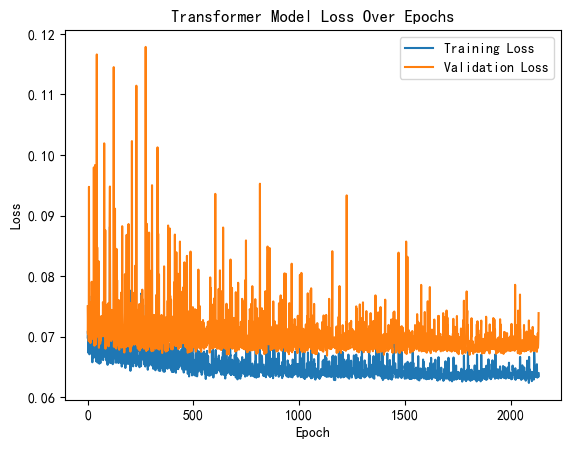

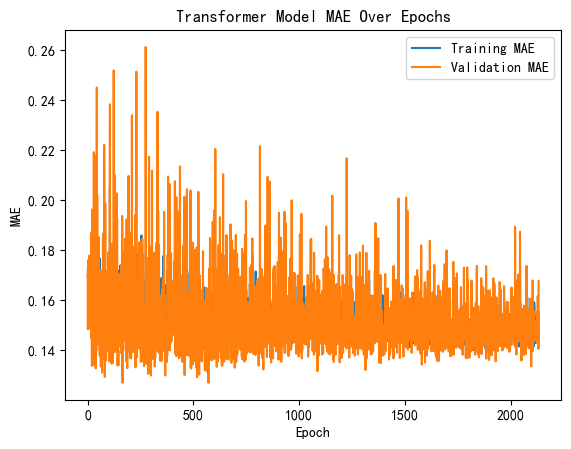

In [185]:
import matplotlib.pyplot as plt

# 假设 history 是 fit 返回的 History 对象
history = tf_history.history  # tf_history = tf_model.fit(...)

# 1）Loss 曲线
plt.figure()
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Transformer Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2）MAE 曲线
plt.figure()
plt.plot(history['mae'], label='Training MAE')
plt.plot(history['val_mae'], label='Validation MAE')
plt.title('Transformer Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()
